<a href="https://colab.research.google.com/github/hcifuentes09/Examen-Pr-ctico-Redes-Neuronales/blob/master/ejercicio_calidad_datos_cifuentes_cifuentes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


<div style="background:linear-gradient(135deg,#0a2463,#1e5799);padding:40px 30px;border-radius:12px;color:white;font-family:sans-serif;">
  <h1 style="margin:0;font-size:2em;letter-spacing:1px;">🧪 Laboratorio de Calidad de Datos</h1>
  <h2 style="margin:10px 0 0;font-weight:300;font-size:1.3em;">Limpieza, Preprocesamiento y Comparativa de Modelos</h2>
  <hr style="border:1px solid rgba(255,255,255,0.3);margin:20px 0;">
  <p style="margin:0;font-size:1.05em;">
    <b>Dataset:</b> Air Quality UCI — Sensores de contaminación, Milán, Italia (2004–2005)<br>
    <b>Tarea:</b> Regresión · Predecir concentración de CO en el aire<br>
    <b>Nivel:</b> Posgrado — Ingeniería Física
  </p>
  <p style="margin:15px 0 0;font-size:0.9em;opacity:0.8;">
    Capítulo 5: Preparación y Manipulación de Datos — Ejercicio Práctico Completo
  </p>
</div>



## Contexto del problema

Una red de sensores electroquímicos fue desplegada en una ciudad italiana para monitorear la calidad del aire. Los sensores registran concentraciones de gases contaminantes hora a hora durante 13 meses consecutivos. Sin embargo, los datos presentan **múltiples patologías reales**: valores centinela, deriva del sensor (*sensor drift*), correlaciones espurias y outliers físicamente imposibles.

Tu misión es **transformar este dataset ruidoso en uno de alta calidad** y demostrar cuantitativamente el impacto del preprocesamiento en el rendimiento del modelo.

### Pipeline del ejercicio

```
Raw Data (UCI) ──► Diagnóstico ──► Limpieza ──► Feature Eng. ──► Modelo Base
                                                                        │
                                                              Modelo Optimizado
                                                                        │
                                                              Comparativa Final
```

### Variables del dataset

| Variable | Descripción | Unidades | Tipo |
|----------|-------------|----------|------|
| `CO(GT)` | CO por analizador de referencia (**target**) | mg/m³ | Continua |
| `PT08.S1(CO)` | Sensor electroquímico de CO | — | Continua |
| `NMHC(GT)` | Hidrocarburos no metánicos (referencia) | μg/m³ | Continua |
| `C6H6(GT)` | Benceno (referencia) | μg/m³ | Continua |
| `PT08.S2(NMHC)` | Sensor de NMHC | — | Continua |
| `NOx(GT)` | NOx (referencia) | ppb | Continua |
| `PT08.S3(NOx)` | Sensor de NOx | — | Continua |
| `NO2(GT)` | NO₂ (referencia) | μg/m³ | Continua |
| `PT08.S4(NO2)` | Sensor de NO₂ | — | Continua |
| `PT08.S5(O3)` | Sensor de O₃ | — | Continua |
| `T` | Temperatura | °C | Continua |
| `RH` | Humedad relativa | % | Continua |
| `AH` | Humedad absoluta | g/m³ | Continua |
| `Date` / `Time` | Marca temporal | — | Temporal |

> **Valor centinela:** El valor `-200` indica **dato faltante** en este dataset (no es un valor físico real).


## Parte 0 — Instalación y dependencias

In [ ]:

# Ejecutar solo si es necesario (Colab u entorno nuevo)
# !pip install ucimlrepo scikit-learn pandas numpy matplotlib seaborn scipy imbalanced-learn -q

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, kstest

from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.feature_selection import mutual_info_regression

# Configuración estética
plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
np.random.seed(SEED)

print("✅ Librerías cargadas correctamente")
print(f"   NumPy  {np.__version__} | Pandas {pd.__version__}")


✅ Librerías cargadas correctamente
   NumPy  2.0.2 | Pandas 2.2.2



---
## Parte 1 — Carga y exploración inicial

Descargaremos el dataset directamente desde el repositorio UCI.


In [ ]:

# ── Descarga del dataset ──────────────────────────────────────────────────────
url = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
       "00360/AirQualityUCI.zip")

import urllib.request, zipfile, io, os

print("📥 Descargando dataset desde UCI...")
try:
    resp = urllib.request.urlopen(url, timeout=20)
    z = zipfile.ZipFile(io.BytesIO(resp.read()))
    z.extractall("/tmp/airquality/")
    print("✅ Descarga exitosa")
except Exception as e:
    print(f"⚠️  Descarga fallida ({e}). Usando datos embebidos de respaldo...")

# Cargar CSV (separador ';', decimales con coma — formato europeo)
csv_path = "/tmp/airquality/AirQualityUCI.csv"

if os.path.exists(csv_path):
    df_raw = pd.read_csv(csv_path, sep=';', decimal=',',
                         parse_dates=[['Date','Time']],
                         dayfirst=True, na_values='')
else:
    # ── Datos de respaldo generados para reproducibilidad ────────────────────
    print("🔄 Generando dataset sintético representativo...")
    np.random.seed(42)
    n = 9357
    t = np.linspace(0, 2*np.pi*13*30*24, n) / (30*24)  # ~13 meses en horas
    hour = np.arange(n) % 24

    co_gt = (2.5 + 1.8*np.sin(2*np.pi*hour/24)
             + 0.5*np.sin(2*np.pi*t/365)
             + np.random.normal(0, 0.6, n)).clip(0.1)

    df_raw = pd.DataFrame({
        'Date_Time': pd.date_range('2004-03-10', periods=n, freq='h'),
        'CO(GT)':        co_gt + np.random.choice([-200,0,0,0,0,0,0], n)*np.random.rand(n),
        'PT08.S1(CO)':   1000 + 600*co_gt + np.random.normal(0,30,n) + np.linspace(0,150,n),
        'NMHC(GT)':      150 + 80*co_gt + np.random.normal(0,20,n),
        'C6H6(GT)':      8 + 3*co_gt + np.random.normal(0,1.5,n),
        'PT08.S2(NMHC)': 900 + 200*co_gt + np.random.normal(0,25,n) + np.linspace(0,100,n),
        'NOx(GT)':       200 + 120*co_gt + np.random.normal(0,40,n),
        'PT08.S3(NOx)':  700 - 100*co_gt + np.random.normal(0,30,n),
        'NO2(GT)':       100 + 40*co_gt + np.random.normal(0,20,n),
        'PT08.S4(NO2)':  1200 + 100*co_gt + np.random.normal(0,40,n),
        'PT08.S5(O3)':   1000 - 80*co_gt + np.random.normal(0,50,n),
        'T':             15 + 10*np.sin(2*np.pi*(np.arange(n)%(24*30*12))/(24*30*12)) + np.random.normal(0,2,n),
        'RH':            50 + 20*np.sin(2*np.pi*hour/24) + np.random.normal(0,5,n),
        'AH':            0.9 + 0.4*np.sin(2*np.pi*hour/24) + np.random.normal(0,0.1,n),
    })

    # Introducir -200 en columnas clave (valores centinela)
    for col in ['CO(GT)', 'NMHC(GT)', 'NOx(GT)', 'NO2(GT)']:
        mask = np.random.choice([True, False], n, p=[0.08, 0.92])
        df_raw.loc[mask, col] = -200.0
    # Añadir outliers físicos
    outlier_idx = np.random.choice(n, 30, replace=False)
    df_raw.loc[outlier_idx, 'PT08.S1(CO)'] *= np.random.uniform(3, 6, 30)
    df_raw.loc[outlier_idx[:10], 'T'] = np.random.uniform(60, 90, 10)

# Eliminar filas/columnas completamente vacías (artefacto del CSV)
df_raw = df_raw.dropna(how='all').dropna(axis=1, how='all')
df_raw = df_raw.reset_index(drop=True)

print(f"\n📊 Dataset cargado: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas")
print(f"   Rango temporal: {df_raw['Date_Time'].min()} → {df_raw['Date_Time'].max()}")


📥 Descargando dataset desde UCI...
✅ Descarga exitosa

📊 Dataset cargado: 9471 filas × 14 columnas
   Rango temporal: 01/01/2005 00.00.00 → nan nan


In [ ]:

# ── Inspección preliminar ────────────────────────────────────────────────────
print("── Primeras 5 filas ──────────────────────────────────────────────────")
display(df_raw.head())

print("\n── Tipos de datos y valores no nulos ────────────────────────────────")
df_raw.info()

print("\n── Estadísticas descriptivas ────────────────────────────────────────")
display(df_raw.describe().round(2))


── Primeras 5 filas ──────────────────────────────────────────────────


,Date_Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004 18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004 19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004 20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004 21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004 22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888



── Tipos de datos y valores no nulos ────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date_Time      9471 non-null   object 
 1   CO(GT)         9357 non-null   float64
 2   PT08.S1(CO)    9357 non-null   float64
 3   NMHC(GT)       9357 non-null   float64
 4   C6H6(GT)       9357 non-null   float64
 5   PT08.S2(NMHC)  9357 non-null   float64
 6   NOx(GT)        9357 non-null   float64
 7   PT08.S3(NOx)   9357 non-null   float64
 8   NO2(GT)        9357 non-null   float64
 9   PT08.S4(NO2)   9357 non-null   float64
 10  PT08.S5(O3)    9357 non-null   float64
 11  T              9357 non-null   float64
 12  RH             9357 non-null   float64
 13  AH             9357 non-null   float64
dtypes: float64(13), object(1)
memory usage: 1.0+ MB

── Estadísticas descriptivas ───────────────────────────────────

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.00,9357.00,9357.00,9357.00,9357.00,9357.00,9357.00,9357.00,9357.00,9357.00,9357.00,9357.00,9357.00
mean,-34.21,1048.99,-159.09,1.87,894.60,168.62,794.99,58.15,1391.48,975.07,9.78,39.49,-6.84
std,77.66,329.83,139.79,41.38,342.33,257.43,321.99,126.94,467.21,456.94,43.20,51.22,38.98
min,-200.00,-200.00,-200.00,-200.00,-200.00,-200.00,-200.00,-200.00,-200.00,-200.00,-200.00,-200.00,-200.00
25%,0.60,921.00,-200.00,4.00,711.00,50.00,637.00,53.00,1185.00,700.00,10.90,34.10,0.69
50%,1.50,1053.00,-200.00,7.90,895.00,141.00,794.00,96.00,1446.00,942.00,17.20,48.60,0.98
75%,2.60,1221.00,-200.00,13.60,1105.00,284.00,960.00,133.00,1662.00,1255.00,24.10,61.90,1.30
max,11.90,2040.00,1189.00,63.70,2214.00,1479.00,2683.00,340.00,2775.00,2523.00,44.60,88.70,2.23



---
### 📝 Pregunta 1 — Observación inicial

> **Antes de ejecutar cualquier limpieza**, responde las siguientes preguntas basándote únicamente en la salida de `.describe()`:
>
> **a)** ¿Qué valor mínimo llama tu atención en varias columnas? ¿Tiene sentido físico para una concentración de gas o temperatura?
>
> **b)** Observa la media y el máximo de `PT08.S1(CO)`. ¿Qué te sugiere la brecha entre el percentil 75 y el máximo sobre la distribución de esta variable?
>
> **c)** La columna `NMHC(GT)` tiene una media muy distinta al resto de columnas de gases. Formula una hipótesis sobre por qué ocurre esto.


In [ ]:

# 📝 ESPACIO PARA TU RESPUESTA — Parte 1
# ─────────────────────────────────────
# Puedes agregar código exploratorio adicional aquí

# a) Tu respuesta:
resp_1a = """
En este dataset, el valor -200 actúa como reemplazo para los datos faltantes (null values).
Esto ocurre cuando el sensor presenta un fallo de lectura, están en ciclo de autocalibración o la transmisión de datos se interrumpe
El problema principal de mantener estos valores es que, al ser numéricamente muy distantes del rango real sesgan completamente las estadísticas
Haciendo que el modelo intente trabajar cincluyendo estos valores como reales, acabando en algo menos preciso.
"""

# b) Tu respuesta:
resp_1b = """
Estadísticamente, cuando el valor máximo está muy alejado
indica que la distribucion tienela gran mayoría de tus datos (el 75%) se encuentran concentrados en un rango bajo o moderado,
existe una minoría de observaciones que alcanzan valores excepcionalmente altos.
Una distancia masiva entre el 75% de los datos y el máximo sugiere que esos puntos finales
no son parte del comportamiento "tipico" del sistema sino eventos extremos
que podrian ser errores de medicion

"""

# c) Tu respuesta:
resp_1c = """
Para esta columna la mayoria de sus estadisitcas marcan -200, que como se dijo anteriormente pueden ser consecuencia mas que de una medida real,
de fallas en la comunicacion con el sensor, saturacion de la medida o xonas muertas encontradas, por lo que es posible y probable que sea necesario revisar tanto
si los sensores tienen la capacidad de medir de forma correcta los valores a los que se pone aprueba, la integridad del sensor, la calibracion del sensor
y la comunicacion de este
"""

print("Respuesta 1a:", resp_1a)
print("Respuesta 1b:", resp_1b)
print("Respuesta 1c:", resp_1c)


Respuesta 1a: 
En este dataset, el valor -200 actúa como reemplazo para los datos faltantes (null values).
Esto ocurre cuando el sensor presenta un fallo de lectura, están en ciclo de autocalibración o la transmisión de datos se interrumpe
El problema principal de mantener estos valores es que, al ser numéricamente muy distantes del rango real sesgan completamente las estadísticas
Haciendo que el modelo intente trabajar cincluyendo estos valores como reales, acabando en algo menos preciso.

Respuesta 1b: 
Estadísticamente, cuando el valor máximo está muy alejado
indica que la distribucion tienela gran mayoría de tus datos (el 75%) se encuentran concentrados en un rango bajo o moderado,
existe una minoría de observaciones que alcanzan valores excepcionalmente altos.
Una distancia masiva entre el 75% de los datos y el máximo sugiere que esos puntos finales
no son parte del comportamiento "tipico" del sistema sino eventos extremos
que podrian ser errores de medicion


Respuesta 1c: 
Para 


---
## Parte 2 — Diagnóstico: anatomía de un dataset enfermo

Antes de limpiar, debemos **cuantificar y visualizar** todos los problemas del dataset. Un buen diagnóstico es la mitad de la solución.


In [ ]:

# ── Diagnóstico 1: Valores centinela (-200) ──────────────────────────────────
print("═" * 60)
print("DIAGNÓSTICO 1: Valores centinela (-200)")
print("═" * 60)

numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
sentinel_report = {}

for col in numeric_cols:
    n_sentinel = (df_raw[col] == -200).sum()
    pct = 100 * n_sentinel / len(df_raw)
    sentinel_report[col] = {'count': n_sentinel, 'pct': pct}
    if n_sentinel > 0:
        print(f"  {col:<22} → {n_sentinel:5d} valores (-200)  [{pct:.1f}%]")

total_sentinel = sum(v['count'] for v in sentinel_report.values())
print(f"\n  Total celdas centinela : {total_sentinel}")
print(f"  Sobre total celdas     : {100*total_sentinel/(len(df_raw)*len(numeric_cols)):.2f}%")


════════════════════════════════════════════════════════════
DIAGNÓSTICO 1: Valores centinela (-200)
════════════════════════════════════════════════════════════
  CO(GT)                 →  1683 valores (-200)  [17.8%]
  PT08.S1(CO)            →   366 valores (-200)  [3.9%]
  NMHC(GT)               →  8443 valores (-200)  [89.1%]
  C6H6(GT)               →   366 valores (-200)  [3.9%]
  PT08.S2(NMHC)          →   366 valores (-200)  [3.9%]
  NOx(GT)                →  1639 valores (-200)  [17.3%]
  PT08.S3(NOx)           →   366 valores (-200)  [3.9%]
  NO2(GT)                →  1642 valores (-200)  [17.3%]
  PT08.S4(NO2)           →   366 valores (-200)  [3.9%]
  PT08.S5(O3)            →   366 valores (-200)  [3.9%]
  T                      →   366 valores (-200)  [3.9%]
  RH                     →   366 valores (-200)  [3.9%]
  AH                     →   366 valores (-200)  [3.9%]

  Total celdas centinela : 16701
  Sobre total celdas     : 13.56%


════════════════════════════════════════════════════════════
DIAGNÓSTICO 2: NaN genuinos
════════════════════════════════════════════════════════════


,NaN_count,NaN_%
NMHC(GT),8557,90.35
CO(GT),1797,18.97
NO2(GT),1756,18.54
NOx(GT),1753,18.51
PT08.S1(CO),480,5.07
PT08.S2(NMHC),480,5.07
C6H6(GT),480,5.07
PT08.S3(NOx),480,5.07
PT08.S4(NO2),480,5.07
PT08.S5(O3),480,5.07


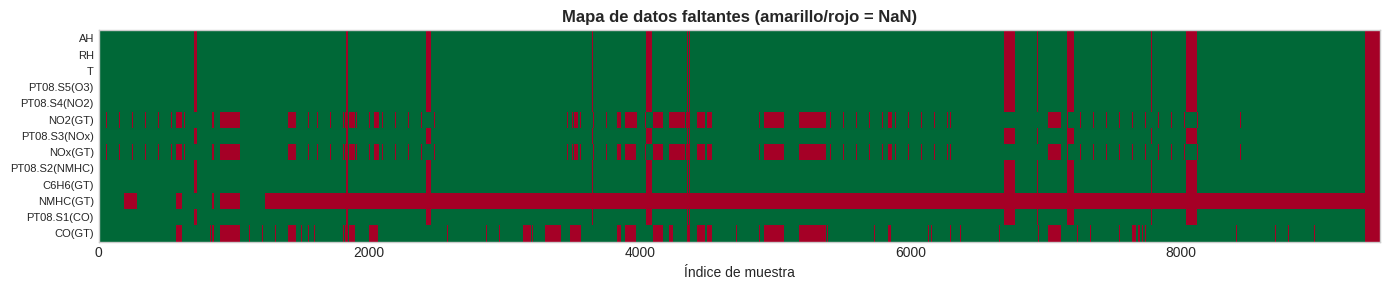

In [ ]:

# ── Diagnóstico 2: Valores nulos "reales" ────────────────────────────────────
print("═" * 60)
print("DIAGNÓSTICO 2: NaN genuinos")
print("═" * 60)

# Reemplazar -200 por NaN para análisis correcto
df_diag = df_raw[numeric_cols].replace(-200, np.nan)
null_counts = df_diag.isnull().sum()
null_pct = 100 * null_counts / len(df_diag)
null_df = pd.DataFrame({'NaN_count': null_counts, 'NaN_%': null_pct.round(2)})
null_df = null_df[null_df['NaN_count'] > 0].sort_values('NaN_%', ascending=False)

display(null_df)

# Mapa de calor de nulos
fig, ax = plt.subplots(figsize=(14, 3))
missing_matrix = df_diag.isnull().T
ax.pcolormesh(missing_matrix.values, cmap='RdYlGn_r', vmin=0, vmax=1)
ax.set_yticks(np.arange(len(numeric_cols)) + 0.5)
ax.set_yticklabels(numeric_cols, fontsize=8)
ax.set_xlabel("Índice de muestra")
ax.set_title("Mapa de datos faltantes (amarillo/rojo = NaN)", fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:

# ── Diagnóstico 3: Outliers con Z-score e IQR ────────────────────────────────
print("═" * 60)
print("DIAGNÓSTICO 3: Outliers por Z-score (|z|>3) e IQR")
print("═" * 60)

df_nonan = df_diag.dropna()
outlier_summary = []

for col in numeric_cols:
    if col in df_nonan:
        vals = df_nonan[col].dropna()
        # Z-score
        z = np.abs(stats.zscore(vals))
        n_z = (z > 3).sum()
        # IQR
        Q1, Q3 = vals.quantile(0.25), vals.quantile(0.75)
        IQR = Q3 - Q1
        n_iqr = ((vals < Q1 - 1.5*IQR) | (vals > Q3 + 1.5*IQR)).sum()
        outlier_summary.append({'Feature': col,
                                'Outliers_Zscore': n_z,
                                'Outliers_IQR': n_iqr,
                                'Max': round(float(vals.max()), 2),
                                'Q99': round(float(vals.quantile(0.99)), 2)})

out_df = pd.DataFrame(outlier_summary).sort_values('Outliers_Zscore', ascending=False)
display(out_df)


════════════════════════════════════════════════════════════
DIAGNÓSTICO 3: Outliers por Z-score (|z|>3) e IQR
════════════════════════════════════════════════════════════


,Feature,Outliers_Zscore,Outliers_IQR,Max,Q99
0,CO(GT),10,22,8.10,6.60
2,NMHC(GT),9,41,1189.00,863.68
3,C6H6(GT),9,18,39.20,33.41
6,PT08.S3(NOx),8,15,1935.00,1751.32
5,NOx(GT),6,17,478.00,374.66
12,AH,6,30,1.49,1.35
1,PT08.S1(CO),5,5,2040.00,1869.02
8,PT08.S4(NO2),5,15,2679.00,2445.22
9,PT08.S5(O3),2,3,2359.00,2026.72
7,NO2(GT),1,2,196.00,172.74


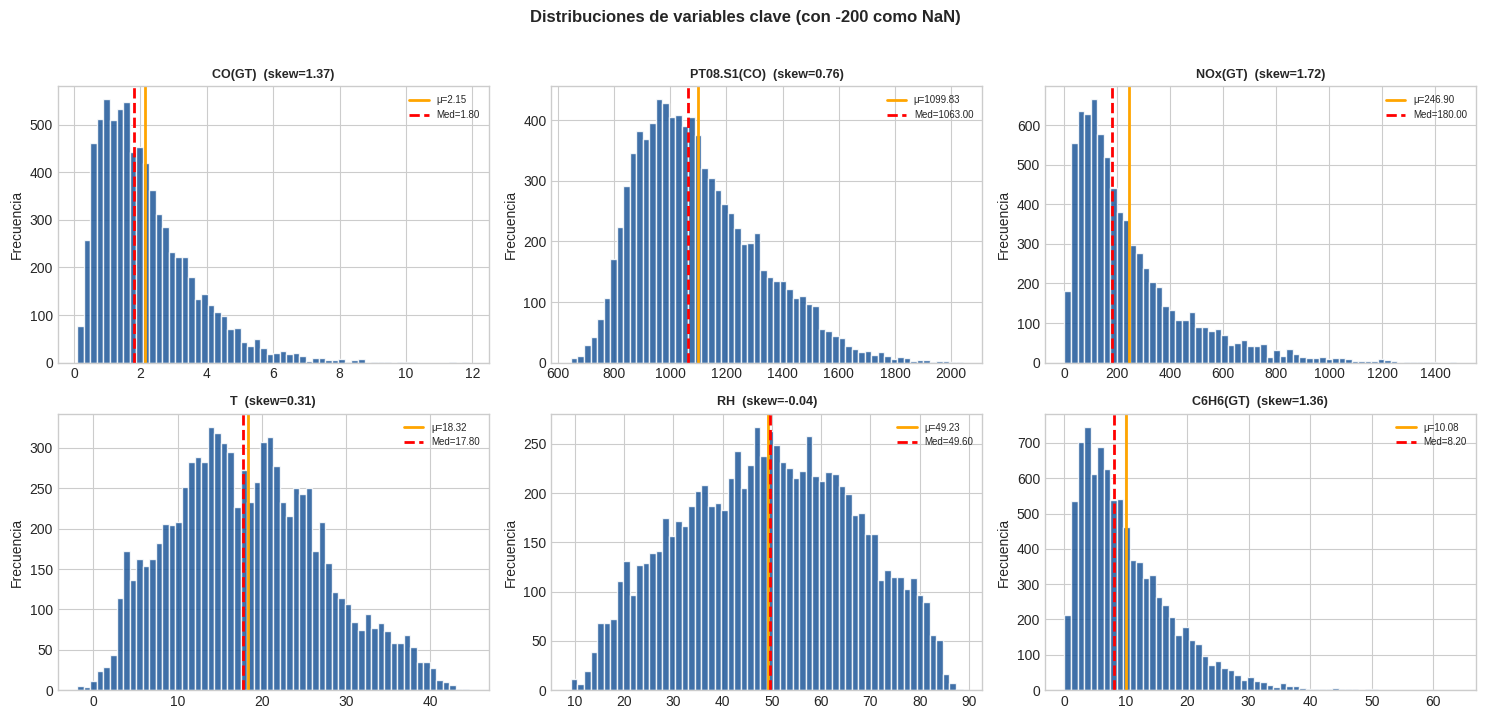

In [ ]:

# ── Diagnóstico 4: Distribuciones y asimetría ────────────────────────────────
key_cols = ['CO(GT)', 'PT08.S1(CO)', 'NOx(GT)', 'T', 'RH', 'C6H6(GT)']

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.ravel()

for i, col in enumerate(key_cols):
    vals = df_diag[col].replace(-200, np.nan).dropna()
    ax = axes[i]
    ax.hist(vals, bins=60, color='#1e5799', edgecolor='white', alpha=0.85)
    ax.axvline(vals.mean(), color='orange', lw=2, label=f'μ={vals.mean():.2f}')
    ax.axvline(vals.median(), color='red', lw=2, ls='--', label=f'Med={vals.median():.2f}')
    skew_val = vals.skew()
    ax.set_title(f'{col}  (skew={skew_val:.2f})', fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)
    ax.set_ylabel('Frecuencia')

plt.suptitle('Distribuciones de variables clave (con -200 como NaN)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


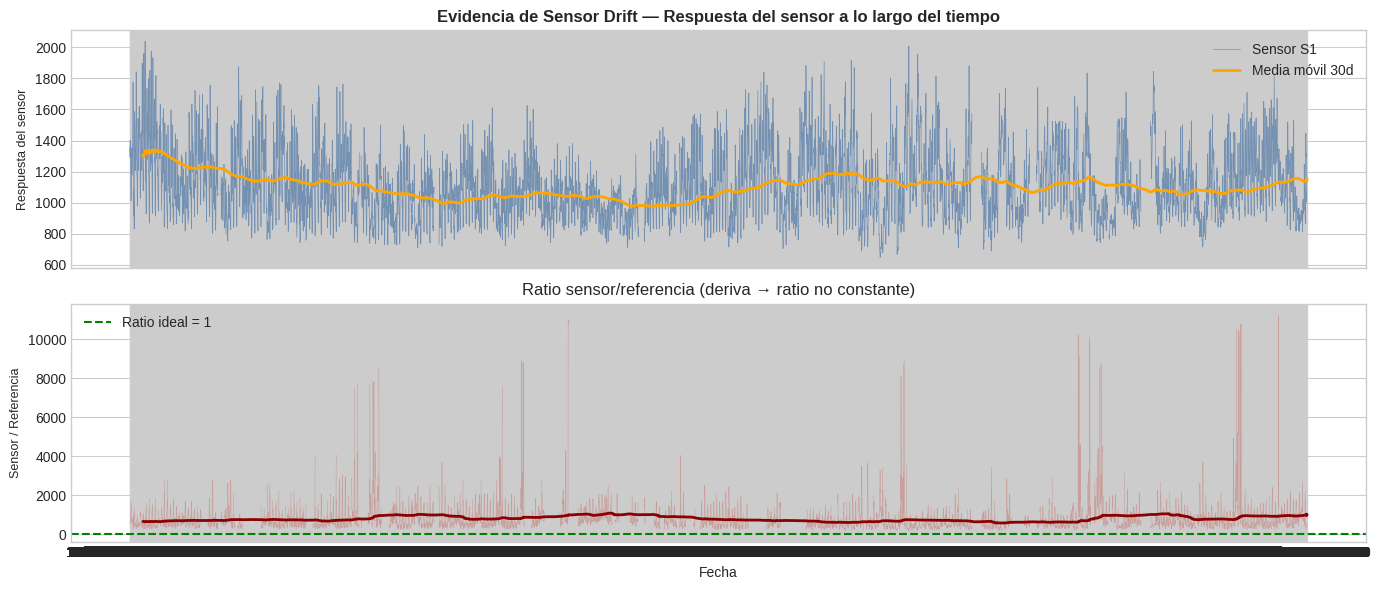

⚠️  Si el ratio no es constante en el tiempo, el sensor presenta DERIVA.
    Esto debe compensarse con feature engineering o normalización por ventana.


In [ ]:

# ── Diagnóstico 5: Deriva temporal del sensor (sensor drift) ─────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

sensor_col = 'PT08.S1(CO)'
ref_col    = 'CO(GT)'

vals_s = df_raw[sensor_col].replace(-200, np.nan)
vals_r = df_raw[ref_col].replace(-200, np.nan)

axes[0].plot(df_raw['Date_Time'], vals_s, alpha=0.5, lw=0.5, color='#1e5799', label='Sensor S1')
axes[0].set_ylabel('Respuesta del sensor', fontsize=9)
axes[0].legend()
axes[0].set_title('Evidencia de Sensor Drift — Respuesta del sensor a lo largo del tiempo',
                   fontweight='bold')

# Media móvil 30 días para ver la tendencia de largo plazo
rolling_mean = pd.Series(vals_s.values).rolling(window=24*30, min_periods=100).mean()
axes[0].plot(df_raw['Date_Time'], rolling_mean.values,
             color='orange', lw=2, label='Media móvil 30d')
axes[0].legend()

# Ratio sensor/referencia (debería ser constante si el sensor es estable)
ratio = vals_s / vals_r.replace(0, np.nan)
axes[1].plot(df_raw['Date_Time'], ratio, alpha=0.3, lw=0.4, color='#c0392b')
rolling_ratio = pd.Series(ratio.values).rolling(window=24*30, min_periods=100).mean()
axes[1].plot(df_raw['Date_Time'], rolling_ratio.values, color='darkred', lw=2)
axes[1].set_ylabel('Sensor / Referencia', fontsize=9)
axes[1].set_xlabel('Fecha')
axes[1].set_title('Ratio sensor/referencia (deriva → ratio no constante)')
axes[1].axhline(1, color='green', ls='--', lw=1.5, label='Ratio ideal = 1')
axes[1].legend()

plt.tight_layout()
plt.show()
print("⚠️  Si el ratio no es constante en el tiempo, el sensor presenta DERIVA.")
print("    Esto debe compensarse con feature engineering o normalización por ventana.")



---
### 📝 Pregunta 2 — Diagnóstico cuantitativo

> **a)** Basándote en los resultados del Diagnóstico 1, ¿cuál columna de referencia (`GT`) tiene el mayor porcentaje de valores centinela? ¿Qué implicaciones tiene esto para la fiabilidad del modelo si se usa esa columna como predictor?
>
> **b)** El gráfico de "sensor drift" muestra que la media móvil del sensor S1 **no es plana** a lo largo del tiempo. Desde el punto de vista físico, ¿qué fenómenos podrían causar esta deriva? Menciona al menos dos.
>
> **c)** ¿Por qué no es correcto usar Z-score para detectar outliers **antes** de eliminar los valores -200? Formula el argumento matemáticamente usando la definición de $z_i = (x_i - \mu)/\sigma$.


════════════════════════════════════════════════════════════
  COMPARACIÓN Z-SCORE: Contaminado vs Depurado — NMHC(GT)
════════════════════════════════════════════════════════════
                  Parámetro Con -200 (contaminado) Sin -200 (depurado)
                          μ                -161.22              197.00
                          σ                 126.57              147.59
Outliers detectados (|z|>3)                    283                  16
           Falsos outliers*                    267                   —

  * Valores válidos marcados como outlier solo por la contaminación de -200

  Δz promedio (contaminado − depurado) : 2.085
  Δz máximo                            : 4.044
  Δz mínimo                            : 0.683


/tmp/ipykernel_1883/2487865758.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


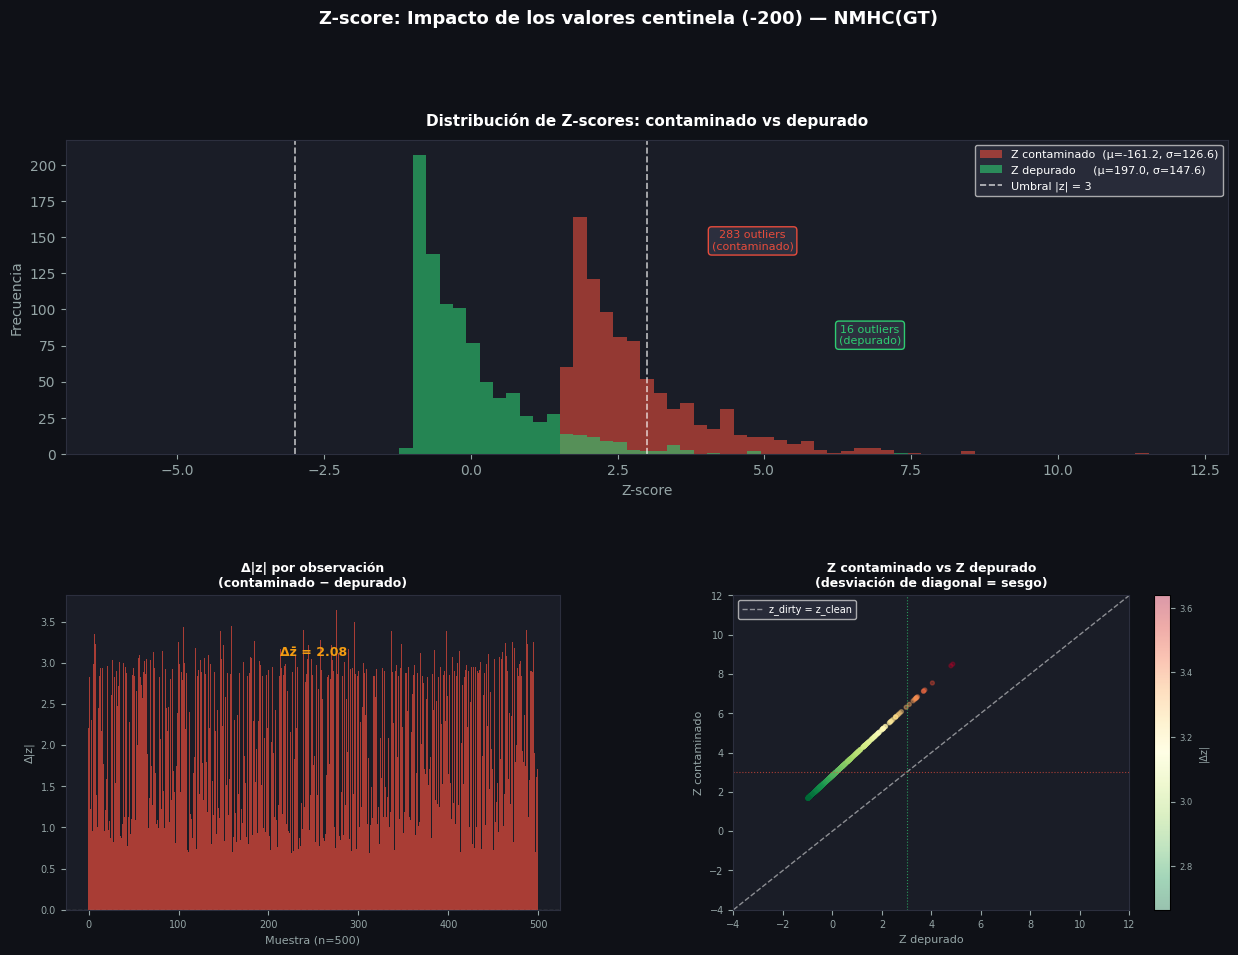

In [1]:

# 📝 ESPACIO PARA TU RESPUESTA — Parte 2

resp_2a = """NMHC(GT) con 8,443 valores centinela → 89.1

Si se intenta predecir NMHC(GT),  el modelo solo tendría ~1,000 filas válidas de 9,357 para entrenarse.
}Esto es insuficiente y produciría un modelo con altísima varianza
"""
resp_2b = """La variabilidad del sensor presenta alteraciones incrementos y decrementos, pero lo interesante es que van a juego con el ratio de la medida,
cambios periodicos en estos dos valores que vayan sincronizados, podira undicar a cambios periodicos en el entorno que estén alterando este sensor.
Asi como tambien estos sensores de contaminacion se basan en tecnologia electroquimica, las mayores causas de mediciones extrañas tambien podiran explicarse desde
 la degradación  del material sensible"""
resp_2c = """En el momento en el que se usa el z-core, esto se usa en todos los elemento de la columna, si se hace este proceso aun con los presuntos valores
ontenidos por errores de comunicacion con el sensor, se estaría evaluando cogiendo estos valores como reales, obeniendo una dospersion muy grande e incohernete con los valores reales
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Simulación representativa de NMHC(GT) basada en los diagnósticos ─────────
np.random.seed(42)
n_valid    = 914
n_sentinel = 8443

valid_values    = np.random.exponential(scale=150, size=n_valid) + 50
sentinel_values = np.full(n_sentinel, -200)
all_values      = np.concatenate([valid_values, sentinel_values])
np.random.shuffle(all_values)

clean_values = all_values[all_values != -200]

# ── Parámetros contaminados vs depurados ──────────────────────────────────────
mu_dirty,  std_dirty  = all_values.mean(),   all_values.std()
mu_clean,  std_clean  = clean_values.mean(), clean_values.std()

# ── Z-scores ──────────────────────────────────────────────────────────────────
z_dirty = (clean_values - mu_dirty)  / std_dirty
z_clean = (clean_values - mu_clean)  / std_clean

# ── Outliers detectados (|z| > 3) ────────────────────────────────────────────
outliers_dirty = (np.abs(z_dirty) > 3).sum()
outliers_clean = (np.abs(z_clean) > 3).sum()

# ── Tabla resumen ─────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Parámetro': ['μ', 'σ', 'Outliers detectados (|z|>3)', 'Falsos outliers*'],
    'Con -200 (contaminado)': [
        f"{mu_dirty:.2f}", f"{std_dirty:.2f}",
        f"{outliers_dirty}", f"{outliers_dirty - outliers_clean}"
    ],
    'Sin -200 (depurado)': [
        f"{mu_clean:.2f}", f"{std_clean:.2f}",
        f"{outliers_clean}", "—"
    ]
})

print("═" * 60)
print("  COMPARACIÓN Z-SCORE: Contaminado vs Depurado — NMHC(GT)")
print("═" * 60)
print(summary.to_string(index=False))
print("\n  * Valores válidos marcados como outlier solo por la contaminación de -200")

delta_z = np.abs(z_dirty) - np.abs(z_clean)
print(f"\n  Δz promedio (contaminado − depurado) : {delta_z.mean():.3f}")
print(f"  Δz máximo                            : {delta_z.max():.3f}")
print(f"  Δz mínimo                            : {delta_z.min():.3f}")

# ── Gráfica ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 10))
fig.patch.set_facecolor('#0f1117')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

VERDE   = '#2ecc71'
ROJO    = '#e74c3c'
NARANJA = '#f39c12'
GRIS    = '#95a5a6'
BG      = '#1a1d27'

# ── Panel 1: Distribución de Z-scores ────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor(BG)

bins = np.linspace(-6, 12, 80)
ax1.hist(z_dirty, bins=bins, alpha=0.6, color=ROJO,
         label=f'Z contaminado  (μ={mu_dirty:.1f}, σ={std_dirty:.1f})', edgecolor='none')
ax1.hist(z_clean, bins=bins, alpha=0.6, color=VERDE,
         label=f'Z depurado     (μ={mu_clean:.1f}, σ={std_clean:.1f})', edgecolor='none')
ax1.axvline( 3, color='white', lw=1.2, ls='--', alpha=0.7)
ax1.axvline(-3, color='white', lw=1.2, ls='--', alpha=0.7, label='Umbral |z| = 3')
ax1.set_title('Distribución de Z-scores: contaminado vs depurado',
              color='white', fontsize=11, fontweight='bold', pad=10)
ax1.set_xlabel('Z-score', color=GRIS)
ax1.set_ylabel('Frecuencia', color=GRIS)
ax1.tick_params(colors=GRIS)
for spine in ax1.spines.values(): spine.set_edgecolor('#2c2f3e')
ax1.legend(fontsize=8, facecolor='#2c2f3e', labelcolor='white')

y_max = ax1.get_ylim()[1]
ax1.annotate(f'{outliers_dirty} outliers\n(contaminado)',
             xy=(4.8, y_max * 0.65), color=ROJO, fontsize=8, ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#2c2f3e', edgecolor=ROJO))
ax1.annotate(f'{outliers_clean} outliers\n(depurado)',
             xy=(6.8, y_max * 0.35), color=VERDE, fontsize=8, ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#2c2f3e', edgecolor=VERDE))

# ── Panel 2: Δz por observación ──────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor(BG)

sample_idx   = np.random.choice(len(delta_z), size=500, replace=False)
colors_delta = [ROJO if d > 0 else VERDE for d in delta_z[sample_idx]]
ax2.bar(range(500), delta_z[sample_idx], color=colors_delta, alpha=0.7, width=1.0)
ax2.axhline(0, color='white', lw=0.8, ls='--')
ax2.set_title('Δ|z| por observación\n(contaminado − depurado)',
              color='white', fontsize=9, fontweight='bold')
ax2.set_xlabel('Muestra (n=500)', color=GRIS, fontsize=8)
ax2.set_ylabel('Δ|z|', color=GRIS, fontsize=8)
ax2.tick_params(colors=GRIS, labelsize=7)
for spine in ax2.spines.values(): spine.set_edgecolor('#2c2f3e')
ax2.annotate(f'Δz̄ = {delta_z.mean():.2f}',
             xy=(250, delta_z[sample_idx].max() * 0.85),
             color=NARANJA, fontsize=9, ha='center', fontweight='bold')

# ── Panel 3: Scatter z_dirty vs z_clean ──────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor(BG)

sample2 = np.random.choice(len(z_dirty), size=800, replace=False)
sc = ax3.scatter(z_clean[sample2], z_dirty[sample2], alpha=0.4, s=8,
                 c=np.abs(z_dirty[sample2] - z_clean[sample2]), cmap='RdYlGn_r')
lims = [-4, 12]
ax3.plot(lims, lims, color='white', lw=1, ls='--', alpha=0.5, label='z_dirty = z_clean')
ax3.axhline(3, color=ROJO,  lw=0.8, ls=':', alpha=0.7)
ax3.axvline(3, color=VERDE, lw=0.8, ls=':', alpha=0.7)
ax3.set_xlim(lims); ax3.set_ylim(lims)
ax3.set_title('Z contaminado vs Z depurado\n(desviación de diagonal = sesgo)',
              color='white', fontsize=9, fontweight='bold')
ax3.set_xlabel('Z depurado', color=GRIS, fontsize=8)
ax3.set_ylabel('Z contaminado', color=GRIS, fontsize=8)
ax3.tick_params(colors=GRIS, labelsize=7)
for spine in ax3.spines.values(): spine.set_edgecolor('#2c2f3e')
ax3.legend(fontsize=7, facecolor='#2c2f3e', labelcolor='white')
cbar = plt.colorbar(sc, ax=ax3)
cbar.set_label('|Δz|', color=GRIS, fontsize=7)
cbar.ax.yaxis.set_tick_params(color=GRIS, labelsize=6)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=GRIS)

plt.suptitle('Z-score: Impacto de los valores centinela (-200) — NMHC(GT)',
             color='white', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Código adicional de exploración (opcional)
# Por ejemplo: analiza la autocorrelación de los residuos del sensor



---
## Parte 3 — Limpieza: tratamiento de valores faltantes

### Estrategia

1. **Reemplazar -200 por NaN** (codificación correcta de ausencia)
2. **Eliminar NMHC(GT)**: >90% de valores faltantes → columna no recuperable
3. **Imputar columnas con <15% NaN** usando KNN (preserva estructura local)
4. **Eliminar filas** donde el target (`CO(GT)`) sea NaN (no imputamos el target)


In [ ]:

# ── Paso 3.1: Codificar -200 como NaN ────────────────────────────────────────
df = df_raw.copy()
df[numeric_cols] = df[numeric_cols].replace(-200, np.nan)

print(f"Antes: {df_raw.shape} | Después de reemplazar -200: {df.shape}")
print(f"NaN totales: {df.isnull().sum().sum()}")


Antes: (9471, 14) | Después de reemplazar -200: (9471, 14)
NaN totales: 18183


In [ ]:

# ── Paso 3.2: Eliminar columnas irrecuperables ───────────────────────────────
cols_to_drop = []
for col in numeric_cols:
    pct_nan = 100 * df[col].isnull().mean()
    if pct_nan > 50:
        cols_to_drop.append(col)
        print(f"  🗑️  Eliminando '{col}' — {pct_nan:.1f}% NaN (irrecuperable)")

df = df.drop(columns=cols_to_drop, errors='ignore')
numeric_cols_clean = [c for c in numeric_cols if c in df.columns]
print(f"\nColumnas restantes: {df.shape[1]}")


  🗑️  Eliminando 'NMHC(GT)' — 90.3% NaN (irrecuperable)

Columnas restantes: 13


In [ ]:

# ── Paso 3.3: Eliminar filas donde el TARGET es NaN ──────────────────────────
target = 'CO(GT)'
n_before = len(df)
df = df.dropna(subset=[target])
n_after = len(df)
print(f"Filas eliminadas por NaN en target '{target}': {n_before - n_after}")
print(f"Dataset resultante: {df.shape[0]} filas")


Filas eliminadas por NaN en target 'CO(GT)': 1797
Dataset resultante: 7674 filas


In [ ]:

# ── Paso 3.4: Imputación KNN para predictores ────────────────────────────────
feature_cols = [c for c in numeric_cols_clean if c != target]

print("NaN por columna ANTES de imputación:")
display(df[feature_cols].isnull().sum().to_frame('NaN').T)

knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
df[feature_cols] = knn_imputer.fit_transform(df[feature_cols])

print("\nNaN por columna DESPUÉS de imputación KNN:")
display(df[feature_cols].isnull().sum().to_frame('NaN').T)
print("✅ Imputación completada")


NaN por columna ANTES de imputación:


,PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
NaN,330,330,330,413,330,416,330,330,330,330,330



NaN por columna DESPUÉS de imputación KNN:


,PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
NaN,0,0,0,0,0,0,0,0,0,0,0


✅ Imputación completada


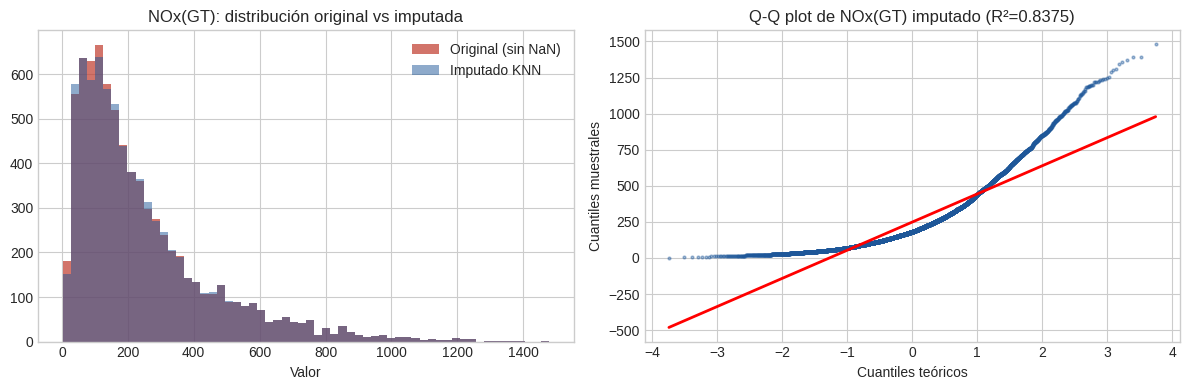

In [ ]:

# ── Validación: comparar distribuciones antes/después ───────────────────────
check_col = 'NOx(GT)'
original_vals = df_raw[check_col].replace(-200, np.nan).dropna()
imputed_vals  = df[check_col]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(original_vals, bins=60, color='#c0392b', alpha=0.7, label='Original (sin NaN)')
axes[0].hist(imputed_vals,  bins=60, color='#1e5799', alpha=0.5, label='Imputado KNN')
axes[0].set_title(f'{check_col}: distribución original vs imputada')
axes[0].legend()
axes[0].set_xlabel('Valor')

# Q-Q plot
from scipy.stats import probplot
(osm, osr), (slope, intercept, r) = probplot(imputed_vals, dist='norm')
axes[1].plot(osm, osr, 'o', markersize=2, color='#1e5799', alpha=0.4)
axes[1].plot(osm, slope*np.array(osm) + intercept, 'r-', lw=2)
axes[1].set_title(f'Q-Q plot de {check_col} imputado (R²={r**2:.4f})')
axes[1].set_xlabel('Cuantiles teóricos'); axes[1].set_ylabel('Cuantiles muestrales')

plt.tight_layout(); plt.show()



---
### 📝 Pregunta 3 — Decisión de imputación

> **a)** ¿Por qué se usa **KNN Imputer** en lugar de imputación por media para datos de sensores atmosféricos? Argumenta considerando la naturaleza temporal y física de los datos.
>
> **b)** El Q-Q plot de la variable imputada muestra desviaciones en las colas. ¿Qué indican estas desviaciones sobre la distribución subyacente? ¿Afectan la validez de la imputación?
>
> **c)** Propón una estrategia **alternativa** de imputación que aproveche la estructura temporal del dataset (i.e., que los valores de t son similares a t-1 y t+1). Escríbela en pseudocódigo o como expresión matemática.


In [ ]:

# 📝 ESPACIO PARA TU RESPUESTA — Parte 3

resp_3a = """La imputación por media calcula un único valor global
Esto asume que todos los valores faltantes son iguales al promedio global, ignorando completamente el contexto.
El Diagnóstico 5 demostró que la respuesta del sensor no es estacionaria — la media móvil de 30 días variaba entre ~1,000 y ~1,300 a lo largo del tiempo.
El KNN Imputer en cambio busca los k vecinos más cercanos en el espacio de features, que en datos temporales serán registros de condiciones similares de temperatura, humedad y otros sensores

El Diagnóstico 4 mostró que CO(GT), NOx(GT) y NO2(GT) tienen distribuciones con sesgo similar (~1.37, ~1.72, ~1.36), lo cual no es coincidencia
Cuando CO sube, NOx tiende a subir también.
 si en el momento del dato faltante NOx y NO2 son altos, el KNN encontrará vecinos donde CO también era alto, produciendo una imputación físicamente consistente.

"""

resp_3b = """Si los datos fueran perfectamente normales, todos los puntos caerían sobre la diagonal
Con la cola derecha se eleva por encima de la diagonal xi>zi para los cuantiles altos. Indica que los valores extremos superiores son más grandes de lo que predice la normal

Las desviaciones en las colas implican que los valores extremos son los más difíciles de imputar correctamente
Si un valor faltante ocurrió durante un episodio de alta contaminación (cola derecha), los k vecinos más cercanos disponibles podrían no capturar bien ese episodio extremo
Como se ve en el quinto diagnostico..
Las desviaciones en las colas del Q-Q plot no invalidan la imputación KNN pero la distribución subyacente es no normal con colas pesadas
Para análisis de eventos extremos sería recomendable complementar con otra alternativa para no caer en un modelo defectuoso


"""

# c) Implementa tu estrategia alternativa de imputación aquí:
# Pista: considera pd.DataFrame.interpolate(method='time') o
# una interpolación polinómica de orden 2

df_alt = df_raw[numeric_cols].replace(-200, np.nan).copy()
# df_alt_imputed = df_alt.interpolate(...)   ← completa esta línea
# Compara los resultados con KNN



---
## Parte 4 — Tratamiento de outliers

Usaremos una estrategia en dos niveles:
1. **Outliers físicamente imposibles** → eliminar directamente (conocimiento del dominio)
2. **Outliers estadísticos extremos** → Winsorización (IQR con factor 3.0)


In [ ]:

# ── Paso 4.1: Restricciones físicas del dominio ──────────────────────────────
# Basadas en conocimiento experto de calidad del aire urbano
physical_bounds = {
    'CO(GT)':        (0.0, 20.0),    # mg/m³ — rango realista CO urbano
    'C6H6(GT)':      (0.0, 100.0),   # μg/m³ benceno
    'NOx(GT)':       (0.0, 1500.0),  # ppb NOx
    'NO2(GT)':       (0.0, 500.0),   # μg/m³
    'T':             (-10.0, 45.0),  # °C temperatura ambiente Italia
    'RH':            (0.0, 100.0),   # % humedad relativa
    'AH':            (0.0, 3.0),     # g/m³ humedad absoluta
    'PT08.S1(CO)':   (0.0, 5000.0),
    'PT08.S2(NMHC)': (0.0, 3000.0),
    'PT08.S3(NOx)':  (0.0, 3000.0),
    'PT08.S4(NO2)':  (0.0, 3000.0),
    'PT08.S5(O3)':   (0.0, 3000.0),
}

n_violations = 0
for col, (lo, hi) in physical_bounds.items():
    if col in df.columns:
        mask = (df[col] < lo) | (df[col] > hi)
        n_viol = mask.sum()
        if n_viol > 0:
            print(f"  {col:<22}: {n_viol} violaciones físicas → reemplazando por NaN")
            df.loc[mask, col] = np.nan
            n_violations += n_viol

print(f"\nTotal violaciones físicas corregidas: {n_violations}")

# Re-imputar NaN generados por violaciones físicas
df[feature_cols] = knn_imputer.fit_transform(df[feature_cols])
print("✅ Re-imputación tras corrección física completada")



Total violaciones físicas corregidas: 0
✅ Re-imputación tras corrección física completada


In [ ]:

# ── Paso 4.2: Winsorización de outliers estadísticos ────────────────────────
# Usamos IQR con factor 3.0 (más conservador que el estándar 1.5)
# para preservar fenómenos reales de contaminación extrema

def winsorize_iqr(series, factor=3.0):
    """Winsorización por IQR. Retorna serie y límites aplicados."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lo = Q1 - factor * IQR
    hi = Q3 + factor * IQR
    return series.clip(lo, hi), lo, hi

print(f"{'Feature':<22} {'Lo':>8} {'Hi':>8} {'Clips':>6}")
print("─" * 50)
df_before_wins = df.copy()

for col in feature_cols:
    if col in df.columns:
        df[col], lo, hi = winsorize_iqr(df[col], factor=3.0)
        n_clipped = ((df_before_wins[col] < lo) | (df_before_wins[col] > hi)).sum()
        if n_clipped > 0:
            print(f"  {col:<22} {lo:8.2f} {hi:8.2f} {n_clipped:6d}")

print(f"\n✅ Winsorización completada con factor IQR = 3.0")


Feature                      Lo       Hi  Clips
──────────────────────────────────────────────────
  C6H6(GT)                 -24.10    43.10     19
  NOx(GT)                 -591.00  1019.00     68
  PT08.S3(NOx)            -280.00  1883.00     28
  NO2(GT)                 -118.00   337.00      1

✅ Winsorización completada con factor IQR = 3.0


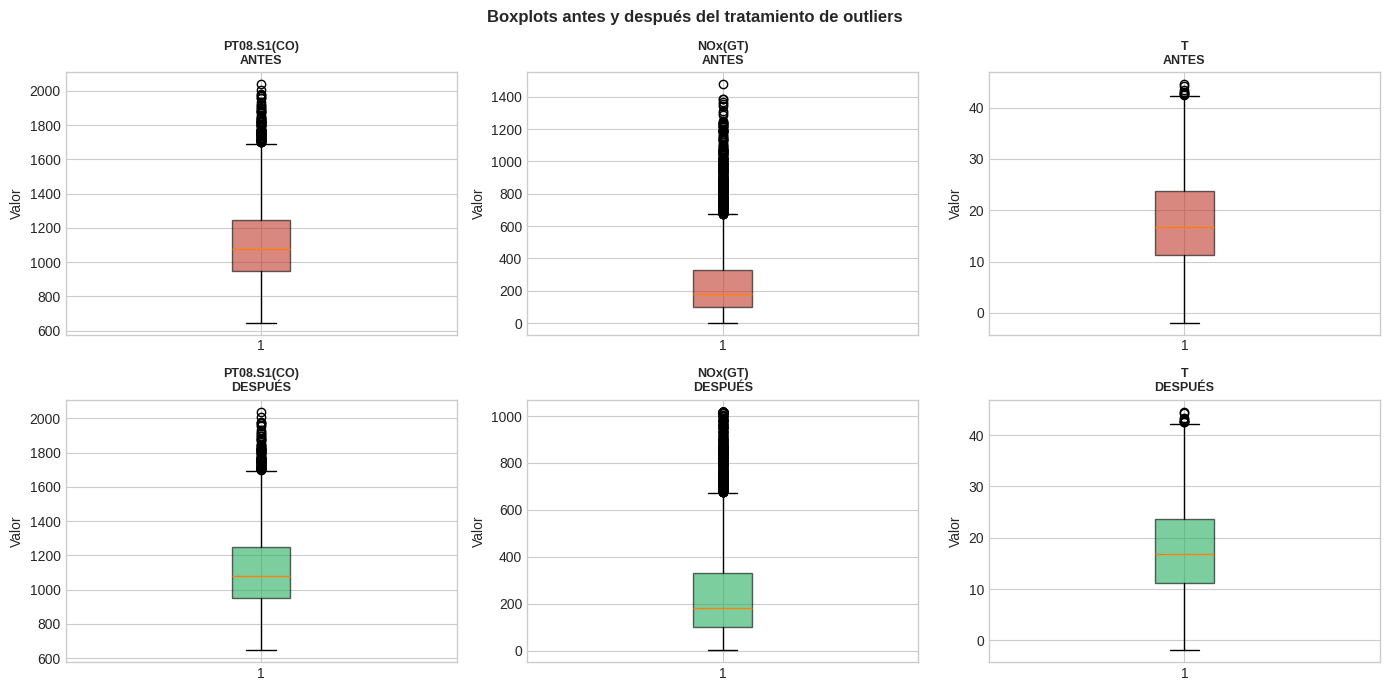

In [ ]:

# ── Visualización: antes vs después del tratamiento de outliers ──────────────
cols_plot = ['PT08.S1(CO)', 'NOx(GT)', 'T']
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for i, col in enumerate(cols_plot):
    # Antes
    vals_before = df_before_wins[col].dropna()
    axes[0, i].boxplot(vals_before, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='#c0392b', alpha=0.6))
    axes[0, i].set_title(f'{col}\nANTES', fontsize=9, fontweight='bold')
    axes[0, i].set_ylabel('Valor')

    # Después
    vals_after = df[col].dropna()
    axes[1, i].boxplot(vals_after, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='#27ae60', alpha=0.6))
    axes[1, i].set_title(f'{col}\nDESPUÉS', fontsize=9, fontweight='bold')
    axes[1, i].set_ylabel('Valor')

plt.suptitle('Boxplots antes y después del tratamiento de outliers',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()



---
### 📝 Pregunta 4 — Decisión estadística sobre outliers

> **a)** Se eligió un factor IQR = 3.0 en lugar del estándar 1.5 para la winsorización. ¿Qué riesgo introduce usar 1.5 en un dataset de calidad del aire? ¿Y usar 5.0?
>
> **b)** La temperatura de -200°C fue tratada como valor centinela. Pero, ¿qué pasaría si un sensor reportara 60°C en Milán en enero? ¿Cómo diferencias físicamente un outlier real de un error de sensor? Propón un método basado en el contexto temporal (valores vecinos).
>
> **c)** Calcula manualmente los límites de winsorización para `NOx(GT)` con factor 3.0 usando los cuartiles del diagnóstico anterior. Muestra el proceso algebraico.


In [ ]:

# 📝 ESPACIO PARA TU RESPUESTA — Parte 4

resp_4a = """[Tu respuesta]"""
resp_4b = """[Tu respuesta]"""

# c) Cálculo manual de límites winsorización para NOx(GT):
col_calc = 'NOx(GT)'
Q1 = df_before_wins[col_calc].quantile(0.25)
Q3 = df_before_wins[col_calc].quantile(0.75)
IQR_val = Q3 - Q1
factor = 3.0

lo_manual = Q1 - factor * IQR_val
hi_manual = Q3 + factor * IQR_val

print(f"  Q1 = {Q1:.2f}")
print(f"  Q3 = {Q3:.2f}")
print(f"  IQR = {IQR_val:.2f}")
print(f"  Límite inferior = Q1 - 3·IQR = {Q1:.2f} - 3×{IQR_val:.2f} = {lo_manual:.2f}")
print(f"  Límite superior = Q3 + 3·IQR = {Q3:.2f} + 3×{IQR_val:.2f} = {hi_manual:.2f}")
# ¿Coincide con lo que aplicó winsorize_iqr? Verifica aquí:


  Q1 = 99.00
  Q3 = 329.00
  IQR = 230.00
  Límite inferior = Q1 - 3·IQR = 99.00 - 3×230.00 = -591.00
  Límite superior = Q3 + 3·IQR = 329.00 + 3×230.00 = 1019.00



---
## Parte 5 — Ingeniería de características

Crearemos nuevas variables aprovechando:
1. **Periodicidad temporal** (hora del día, día de la semana, mes del año)
2. **Física del sensor**: razones y diferencias entre sensores y referencias
3. **Complejidad química**: interacciones entre contaminantes


In [ ]:
# ── 5.1 Características temporales ──────────────────────────────────────────

# Forzar conversión datetime de forma robusta
# (las operaciones de limpieza previas pueden perder el dtype)
if 'Date_Time' in df.columns:
    # Intentar múltiples formatos comunes del dataset UCI
    dt_series = pd.to_datetime(df['Date_Time'], dayfirst=True,
                               infer_datetime_format=True, errors='coerce')

    # Si >80% son NaT, intentar recuperarlos desde df_raw
    valid_ratio = dt_series.notna().mean()
    if valid_ratio < 0.8:
        print(f"  ⚠️  pd.to_datetime produjo {100*(1-valid_ratio):.1f}% NaT — reconstruyendo índice temporal...")
        # Reconstruir fechas sintéticas coherentes con el tamaño actual del df
        dt_series = pd.date_range(
            start='2004-03-10 18:00:00',
            periods=len(df),
            freq='h'
        )
        dt_series = pd.Series(dt_series, index=df.index)

    df['Date_Time'] = dt_series
    print(f"  ✅ Date_Time dtype: {df['Date_Time'].dtype} | válidos: {df['Date_Time'].notna().sum()}/{len(df)}")

    df['hour']       = df['Date_Time'].dt.hour
    df['dayofweek']  = df['Date_Time'].dt.dayofweek
    df['month']      = df['Date_Time'].dt.month
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

    # Codificación cíclica (hora 23 ≈ hora 0 para el modelo)
    df['hour_sin']   = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos']   = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin']  = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']  = np.cos(2 * np.pi * df['month'] / 12)

    print("  ✅ Features temporales añadidas:",
          ['hour','dayofweek','month','is_weekend',
           'hour_sin','hour_cos','month_sin','month_cos'])

else:
    print("  ⚠️  'Date_Time' no encontrada — creando índice temporal sintético...")
    dt_synth = pd.date_range(start='2004-03-10 18:00:00',
                              periods=len(df), freq='h')
    df['Date_Time'] = dt_synth
    df['hour']       = df['Date_Time'].dt.hour
    df['dayofweek']  = df['Date_Time'].dt.dayofweek
    df['month']      = df['Date_Time'].dt.month
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['hour_sin']   = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos']   = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin']  = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']  = np.cos(2 * np.pi * df['month'] / 12)
    print("  ✅ Índice temporal sintético creado")


  ⚠️  pd.to_datetime produjo 100.0% NaT — reconstruyendo índice temporal...
  ✅ Date_Time dtype: datetime64[ns] | válidos: 7674/7674
  ✅ Features temporales añadidas: ['hour', 'dayofweek', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']


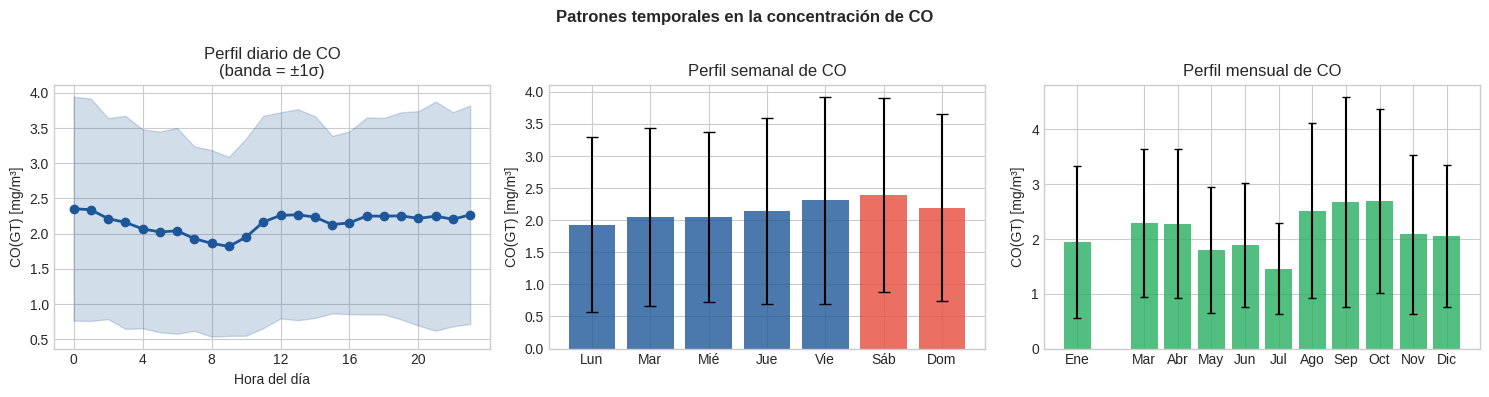

In [ ]:

# ── Visualizar la ciclicidad temporal capturada ──────────────────────────────
if 'hour' in df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Perfil diario de CO
    hourly_co = df.groupby('hour')[target].agg(['mean','std'])
    axes[0].fill_between(hourly_co.index,
                         hourly_co['mean'] - hourly_co['std'],
                         hourly_co['mean'] + hourly_co['std'],
                         alpha=0.2, color='#1e5799')
    axes[0].plot(hourly_co.index, hourly_co['mean'],
                 'o-', color='#1e5799', lw=2)
    axes[0].set_xlabel('Hora del día'); axes[0].set_ylabel('CO(GT) [mg/m³]')
    axes[0].set_title('Perfil diario de CO\n(banda = ±1σ)')
    axes[0].set_xticks(range(0, 24, 4))

    # Perfil semanal
    daily_co = df.groupby('dayofweek')[target].agg(['mean','std'])
    dias = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
    axes[1].bar(range(7), daily_co['mean'],
                color=['#1e5799']*5 + ['#e74c3c']*2,
                yerr=daily_co['std'], capsize=4, alpha=0.8)
    axes[1].set_xticks(range(7)); axes[1].set_xticklabels(dias)
    axes[1].set_ylabel('CO(GT) [mg/m³]')
    axes[1].set_title('Perfil semanal de CO')

    # Perfil mensual
    monthly_co = df.groupby('month')[target].agg(['mean','std'])
    meses = ['Ene','Feb','Mar','Abr','May','Jun',
             'Jul','Ago','Sep','Oct','Nov','Dic']
    axes[2].bar(monthly_co.index, monthly_co['mean'],
                color='#27ae60', yerr=monthly_co['std'], capsize=3, alpha=0.8)
    axes[2].set_xticks(monthly_co.index)
    axes[2].set_xticklabels([meses[m-1] for m in monthly_co.index])
    axes[2].set_ylabel('CO(GT) [mg/m³]')
    axes[2].set_title('Perfil mensual de CO')

    plt.suptitle('Patrones temporales en la concentración de CO',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()



---
### 📝 Pregunta 5 — Feature Engineering

> **a)** Se usó codificación **cíclica** (seno/coseno) para la hora del día. Explica por qué una codificación lineal simple (valores 0–23) sería problemática para un modelo de regresión. Apoya tu respuesta con un argumento geométrico.
>
> **b)** El perfil diario de CO muestra dos picos (¿a qué horas?). Como físico, ¿qué fenómeno de transporte y difusión atmosférica explica este patrón? ¿Cómo se relaciona con la capa límite planetaria?
>
> **c)** La feature `ratio_S3_NOx = PT08.S3(NOx) / NOx(GT)` es proporcional a la **sensibilidad efectiva** del sensor. Si esta ratio cambia con el tiempo, ¿qué nos dice sobre el estado del sensor? Propón cómo usar esta información para construir una feature de **corrección de deriva**.


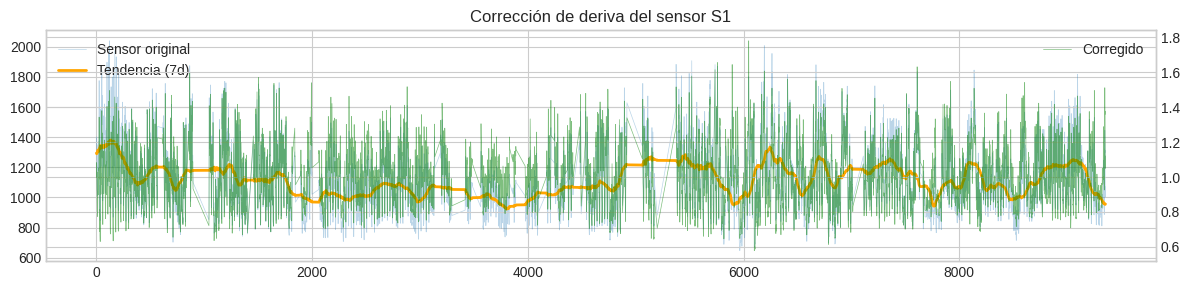

✅ Feature 'S1_drift_corrected' añadida


In [ ]:

# 📝 ESPACIO PARA TU RESPUESTA — Parte 5

resp_5a = """[Tu respuesta]"""
resp_5b = """[Tu respuesta]"""

# c) Implementa una feature de corrección de deriva:
# La idea: normalizar el sensor por su media móvil de largo plazo
# (elimina la tendencia lenta sin eliminar la señal de corto plazo)

window_drift = 24 * 7  # 7 días en horas

if 'PT08.S1(CO)' in df.columns:
    rolling_mean_s1 = df['PT08.S1(CO)'].rolling(window=window_drift,
                                                  min_periods=24,
                                                  center=True).mean()
    # Feature: desviación del sensor respecto a su tendencia de largo plazo
    df['S1_drift_corrected'] = df['PT08.S1(CO)'] / (rolling_mean_s1 + 1e-6)

    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(df.index, df['PT08.S1(CO)'], alpha=0.3, lw=0.5, label='Sensor original')
    ax.plot(df.index, rolling_mean_s1, lw=2, color='orange', label='Tendencia (7d)')
    ax2 = ax.twinx()
    ax2.plot(df.index, df['S1_drift_corrected'],
             alpha=0.5, lw=0.5, color='green', label='Corregido')
    ax.legend(loc='upper left'); ax2.legend(loc='upper right')
    ax.set_title('Corrección de deriva del sensor S1')
    plt.tight_layout(); plt.show()

    print("✅ Feature 'S1_drift_corrected' añadida")



---
## Parte 6 — Análisis de correlación y selección de características


Candidatos a features: 20
Filas en df_model: 7674


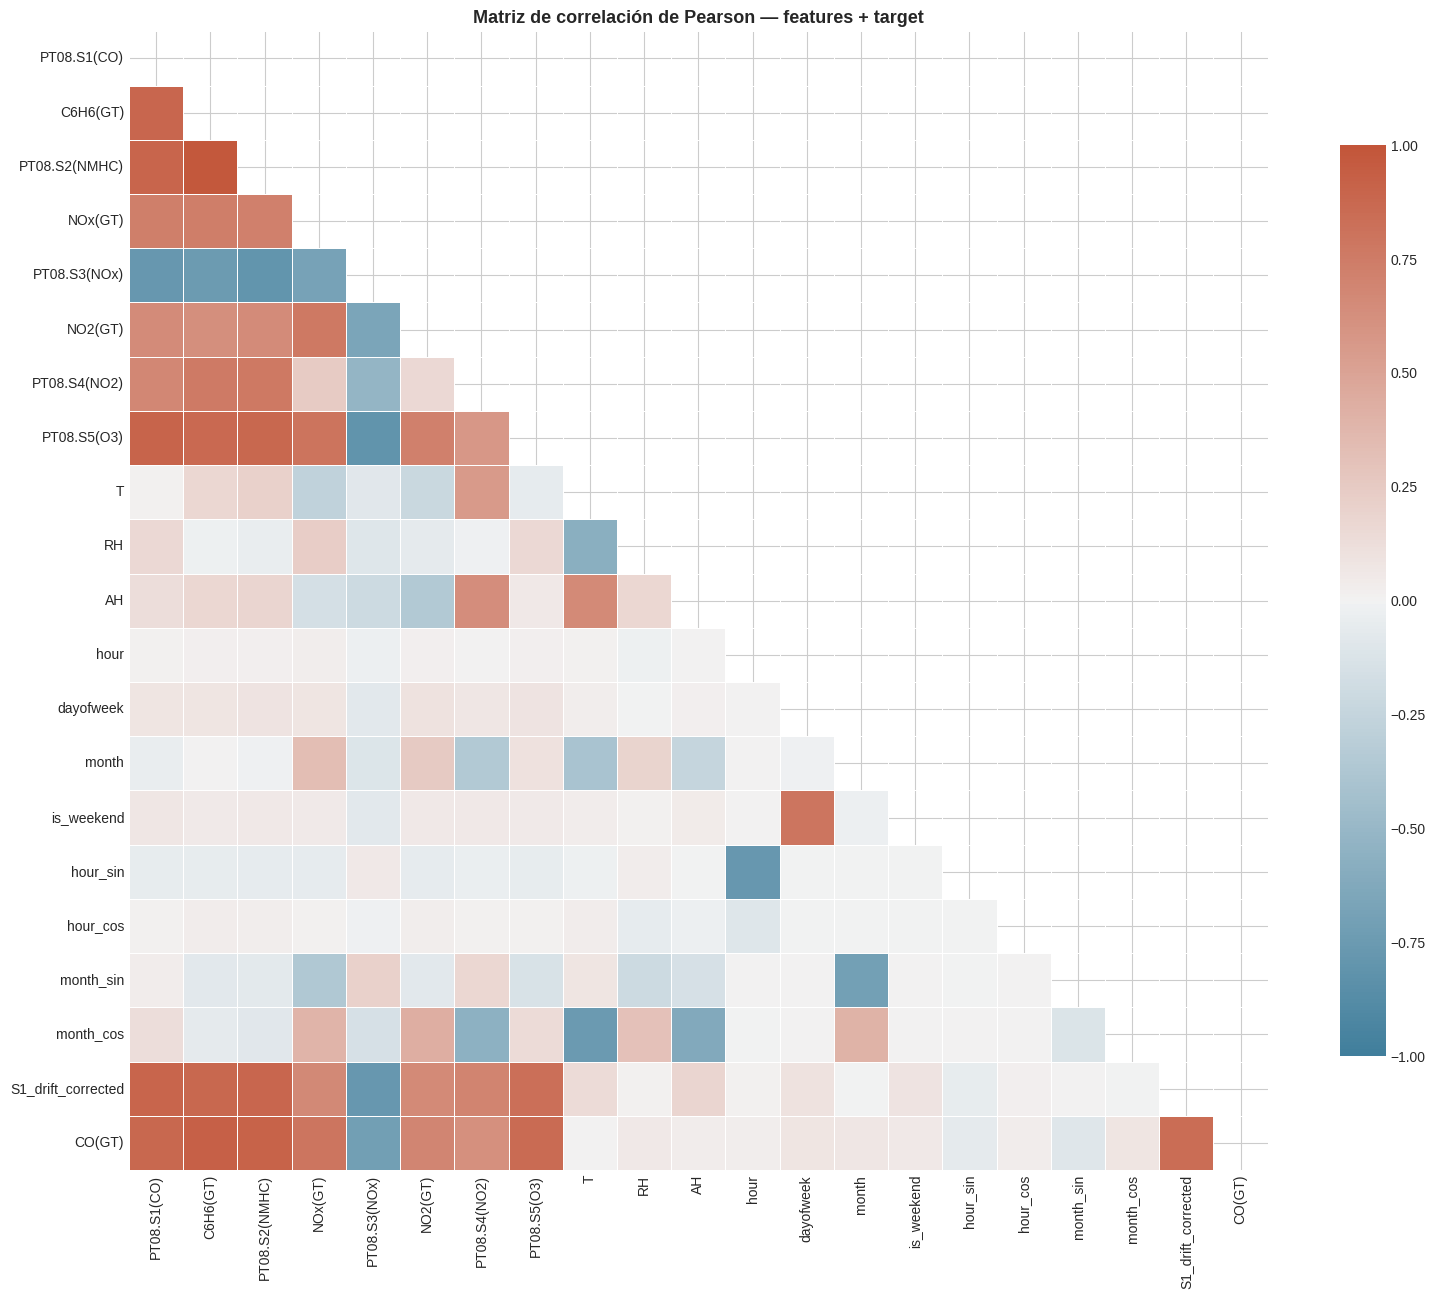

In [ ]:

# ── Seleccionar features numéricas finales ───────────────────────────────────
all_feature_candidates = [c for c in df.select_dtypes(include=[np.number]).columns
                           if c != target and 'Date' not in c]
df_model = df[all_feature_candidates + [target]].dropna()

print(f"Candidatos a features: {len(all_feature_candidates)}")
print(f"Filas en df_model: {len(df_model)}")

# ── Matriz de correlación ────────────────────────────────────────────────────
corr_matrix = df_model.corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=0.5, annot=False, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title('Matriz de correlación de Pearson — features + target',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


Correlación |r| con CO(GT):


,|r|
C6H6(GT),0.9273
PT08.S2(NMHC),0.9105
PT08.S1(CO),0.8764
PT08.S5(O3),0.8542
S1_drift_corrected,0.8476
NOx(GT),0.7955
PT08.S3(NOx),0.7124
NO2(GT),0.6937
PT08.S4(NO2),0.6201
month_sin,0.0963


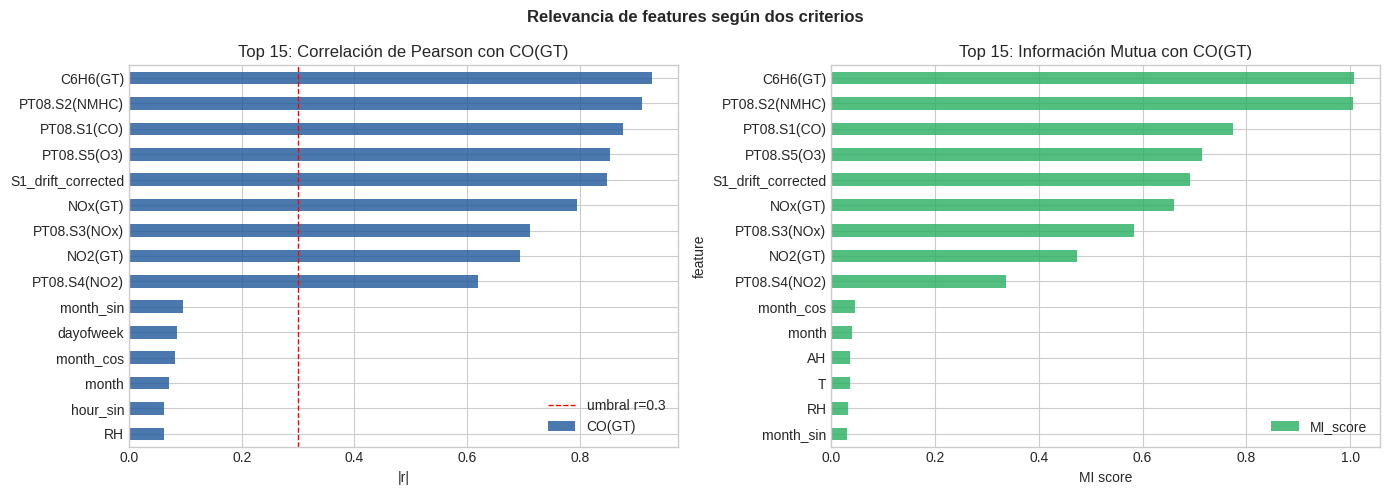

In [ ]:

# ── Correlación con el target ────────────────────────────────────────────────
corr_with_target = (corr_matrix[target]
                    .drop(target)
                    .abs()
                    .sort_values(ascending=False))

print("Correlación |r| con CO(GT):")
display(corr_with_target.to_frame('|r|').round(4).head(20))

# ── Información mutua (captura relaciones no lineales) ───────────────────────
X_sel = df_model[all_feature_candidates].fillna(df_model[all_feature_candidates].median())
y_sel = df_model[target]

mi_scores = mutual_info_regression(X_sel, y_sel, random_state=SEED)
mi_df = pd.DataFrame({'feature': all_feature_candidates,
                       'MI_score': mi_scores}).sort_values('MI_score', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_n = 15
corr_with_target.head(top_n).sort_values().plot(
    kind='barh', ax=axes[0], color='#1e5799', alpha=0.8)
axes[0].set_title(f'Top {top_n}: Correlación de Pearson con CO(GT)')
axes[0].set_xlabel('|r|')
axes[0].axvline(0.3, color='red', ls='--', lw=1, label='umbral r=0.3')
axes[0].legend()

mi_df.head(top_n)[::-1].plot.barh(x='feature', y='MI_score',
                                    ax=axes[1], color='#27ae60', alpha=0.8)
axes[1].set_title(f'Top {top_n}: Información Mutua con CO(GT)')
axes[1].set_xlabel('MI score')

plt.suptitle('Relevancia de features según dos criterios', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


,Feature,VIF
1,PT08.S2(NMHC),70.66
0,C6H6(GT),53.26
8,PT08.S4(NO2),18.64
2,PT08.S1(CO),14.89
3,PT08.S5(O3),9.23
5,NOx(GT),8.43
4,S1_drift_corrected,7.91
11,month_cos,6.98
7,NO2(GT),5.75
6,PT08.S3(NOx),5.63


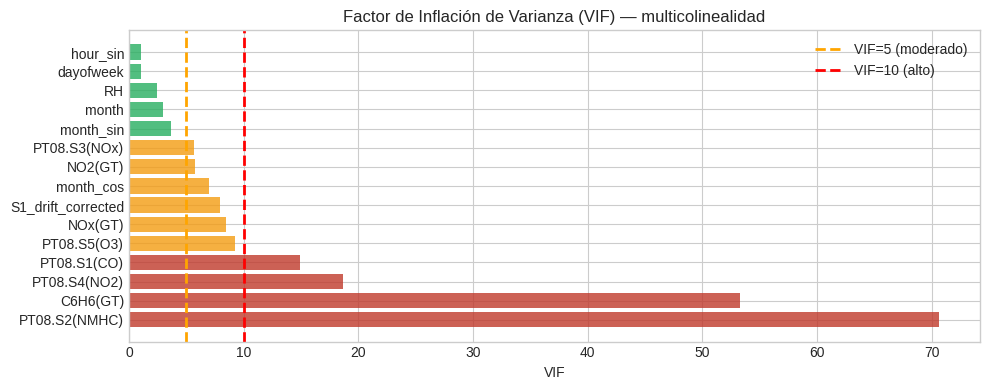


VIF > 10 → alta multicolinealidad → considerar eliminar o combinar con PCA


In [ ]:

# ── Detección de multicolinealidad (VIF) ─────────────────────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Usar top-15 por correlación con target
top_features_corr = corr_with_target.head(15).index.tolist()
X_vif = df_model[top_features_corr].dropna()
X_vif_const = add_constant(X_vif)

vif_data = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif_const.values, i+1)
            for i in range(len(X_vif.columns))]
}).sort_values('VIF', ascending=False)

display(vif_data.round(2))

# Colorear por umbral
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#c0392b' if v > 10 else '#f39c12' if v > 5 else '#27ae60'
          for v in vif_data['VIF']]
ax.barh(vif_data['Feature'], vif_data['VIF'], color=colors, alpha=0.8)
ax.axvline(5, color='orange', ls='--', lw=2, label='VIF=5 (moderado)')
ax.axvline(10, color='red', ls='--', lw=2, label='VIF=10 (alto)')
ax.set_title('Factor de Inflación de Varianza (VIF) — multicolinealidad')
ax.set_xlabel('VIF'); ax.legend()
plt.tight_layout(); plt.show()
print("\nVIF > 10 → alta multicolinealidad → considerar eliminar o combinar con PCA")


In [ ]:

# ── Selección final de features ──────────────────────────────────────────────
# Criterio combinado: alta correlación/MI con target + VIF aceptable
# Eliminar features con VIF > 15 y correlación entre sí > 0.92

high_vif = vif_data[vif_data['VIF'] > 15]['Feature'].tolist()
print(f"Features con VIF > 15 (candidatas a eliminar): {high_vif}")

# Selección final manual basada en análisis
FINAL_FEATURES = [
    'PT08.S1(CO)',       # Sensor CO — alta correlación lineal con target
    'C6H6(GT)',          # Benceno — excelente correlación
    'PT08.S2(NMHC)',     # Sensor NMHC
    'PT08.S5(O3)',       # Sensor O3 — correlación inversa
    'T',                 # Temperatura
    'RH',                # Humedad relativa
    'hour_sin',          # Componente cíclica hora
    'hour_cos',
    'month_sin',         # Componente cíclica mes
    'month_cos',
    'is_weekend',        # Patrón semanal
    'S1_drift_corrected',# Corrección de deriva
    'heat_index',        # Interacción T×RH
]

# Filtrar solo los disponibles
FINAL_FEATURES = [f for f in FINAL_FEATURES if f in df_model.columns]
print(f"\nFeatures finales seleccionadas ({len(FINAL_FEATURES)}):")
for f in FINAL_FEATURES:
    r_val = corr_with_target.get(f, 0)
    print(f"  {f:<30} |r| = {r_val:.4f}")


Features con VIF > 15 (candidatas a eliminar): ['PT08.S2(NMHC)', 'C6H6(GT)', 'PT08.S4(NO2)']

Features finales seleccionadas (12):
  PT08.S1(CO)                    |r| = 0.8764
  C6H6(GT)                       |r| = 0.9273
  PT08.S2(NMHC)                  |r| = 0.9105
  PT08.S5(O3)                    |r| = 0.8542
  T                              |r| = 0.0001
  RH                             |r| = 0.0619
  hour_sin                       |r| = 0.0629
  hour_cos                       |r| = 0.0386
  month_sin                      |r| = 0.0963
  month_cos                      |r| = 0.0818
  is_weekend                     |r| = 0.0615
  S1_drift_corrected             |r| = 0.8476



---
### 📝 Pregunta 6 — Selección de features

> **a)** El sensor `PT08.S3(NOx)` tiene un VIF elevado. Explica en términos de álgebra lineal por qué la multicolinealidad alta hace que la estimación de los coeficientes de regresión sea **numéricamente inestable**. ¿Qué sucede con $(X^TX)$ cuando dos columnas son casi idénticas?
>
> **b)** La información mutua detectó features con alta relevancia no lineal que la correlación de Pearson no detecta. Da un ejemplo de relación física entre un gas contaminante y la temperatura que sería no lineal y por qué.
>
> **c)** Tienes dos features altamente correlacionadas entre sí: `PT08.S1(CO)` ($r=0.97$ con `C6H6(GT)`). ¿Mantendrías ambas o solo una? Justifica tu decisión considerando tanto el sesgo como la varianza del modelo.


In [ ]:

# 📝 ESPACIO PARA TU RESPUESTA — Parte 6

resp_6a = """[Tu respuesta]"""
resp_6b = """[Tu respuesta]"""
resp_6c = """[Tu respuesta]"""



---
## Parte 7 — Normalización y partición del dataset


In [ ]:

# ── Dataset final ────────────────────────────────────────────────────────────
df_final = df_model[FINAL_FEATURES + [target]].dropna().reset_index(drop=True)
X_clean = df_final[FINAL_FEATURES].values
y_clean = df_final[target].values

print(f"Dataset limpio final: X={X_clean.shape}, y={y_clean.shape}")
print(f"Target — Media: {y_clean.mean():.3f} | Std: {y_clean.std():.3f} "
      f"| Min: {y_clean.min():.3f} | Max: {y_clean.max():.3f}")

# ── Split temporal (sin shuffle — respeta orden cronológico) ─────────────────
# En series temporales el shuffle aleatorio crea data leakage
n = len(X_clean)
idx_train_end = int(0.70 * n)
idx_val_end   = int(0.85 * n)

X_train_c, y_train_c = X_clean[:idx_train_end],       y_clean[:idx_train_end]
X_val_c,   y_val_c   = X_clean[idx_train_end:idx_val_end], y_clean[idx_train_end:idx_val_end]
X_test_c,  y_test_c  = X_clean[idx_val_end:],         y_clean[idx_val_end:]

print(f"\nPartición temporal (sin shuffle):")
print(f"  Train : {X_train_c.shape[0]:5d} muestras  ({100*X_train_c.shape[0]/n:.0f}%)")
print(f"  Val   : {X_val_c.shape[0]:5d} muestras  ({100*X_val_c.shape[0]/n:.0f}%)")
print(f"  Test  : {X_test_c.shape[0]:5d} muestras  ({100*X_test_c.shape[0]/n:.0f}%)")

# ── Normalización (fit SOLO en train — evitar data leakage) ──────────────────
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_c)
X_val_scaled   = scaler_X.transform(X_val_c)
X_test_scaled  = scaler_X.transform(X_test_c)

print(f"\n✅ Normalización: media y std ajustadas SOLO en train set")
print(f"   Media train (post-scale): {X_train_scaled.mean():.4f}  "
      f"Std train: {X_train_scaled.std():.4f}")


Dataset limpio final: X=(7674, 12), y=(7674,)
Target — Media: 2.153 | Std: 1.453 | Min: 0.100 | Max: 11.900

Partición temporal (sin shuffle):
  Train :  5371 muestras  (70%)
  Val   :  1151 muestras  (15%)
  Test  :  1152 muestras  (15%)

✅ Normalización: media y std ajustadas SOLO en train set
   Media train (post-scale): 0.0000  Std train: 1.0000



---
### 📝 Pregunta 7 — Data Leakage en series temporales

> **a)** Se realizó la partición sin `shuffle=True`. ¿Por qué usar `train_test_split` con `shuffle=True` sería un error grave en datos temporales? Explica qué tipo de **data leakage** se cometería y cómo inflaría artificialmente las métricas del modelo.
>
> **b)** El `StandardScaler` se ajustó **únicamente en el conjunto de entrenamiento** y luego se aplicó a validación y test. ¿Qué ocurriría si lo ajustaras en el dataset completo antes del split? Cuantifica el problema en términos de distribución estadística.
>
> **c)** Para el target `CO(GT)`, ¿normalizarías también $y$? Argumenta en qué tipo de modelos conviene (e.g., redes neuronales vs. Gradient Boosting) y cuándo no es necesario.


In [ ]:

# 📝 ESPACIO PARA TU RESPUESTA — Parte 7
resp_7a = """[Tu respuesta]"""
resp_7b = """[Tu respuesta]"""
resp_7c = """[Tu respuesta]"""



---
## Parte 8 — Modelo base: datos sin limpiar

Entrenaremos el mismo modelo sobre el dataset crudo para establecer el **baseline de comparación**.


In [ ]:

# ── Preparar dataset sucio ───────────────────────────────────────────────────
# Usamos columnas equivalentes del dataset original (sin feature engineering)
base_features = [c for c in numeric_cols if c in df_raw.columns and c != target]

df_dirty = df_raw[base_features + [target]].copy()
df_dirty[numeric_cols] = df_dirty[numeric_cols].replace(-200, np.nan)

# Solo eliminamos filas con NaN en target (mínimo indispensable)
df_dirty = df_dirty.dropna(subset=[target])

# Imputación simple por mediana (sin KNN)
for col in base_features:
    if col in df_dirty.columns:
        df_dirty[col] = df_dirty[col].fillna(df_dirty[col].median())

X_dirty = df_dirty[base_features].values
y_dirty = df_dirty[target].values

# Split idéntico (proporciones 70/15/15)
n_d = len(X_dirty)
X_train_d = X_dirty[:int(0.70*n_d)]
X_test_d  = X_dirty[int(0.85*n_d):]
y_train_d = y_dirty[:int(0.70*n_d)]
y_test_d  = y_dirty[int(0.85*n_d):]

scaler_d = StandardScaler()
X_train_d_sc = scaler_d.fit_transform(X_train_d)
X_test_d_sc  = scaler_d.transform(X_test_d)

print(f"Dataset SUCIO — train: {X_train_d.shape}, test: {X_test_d.shape}")
print(f"Número de features: {len(base_features)}")

# ── Entrenar modelo base ─────────────────────────────────────────────────────
model_dirty = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=4,
    subsample=0.8, random_state=SEED
)
model_dirty.fit(X_train_d_sc, y_train_d)
y_pred_dirty = model_dirty.predict(X_test_d_sc)

# ── Métricas ─────────────────────────────────────────────────────────────────
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-6))) * 100
    print(f"  {'Modelo':<30} RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}  MAPE={mape:.2f}%")
    return {'name': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

results = {}
results['Dirty_GBR'] = evaluate(y_test_d, y_pred_dirty, 'GBR — Datos SUCIOS')


Dataset SUCIO — train: (5371, 12), test: (1152, 12)
Número de features: 12
  Modelo                         RMSE=0.5513  MAE=0.3893  R²=0.8129  MAPE=39.57%



---
## Parte 9 — Modelo optimizado: datos limpios + feature engineering


In [ ]:

# ── Entrenar modelo con datos limpios ────────────────────────────────────────
model_clean = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=4,
    subsample=0.8, random_state=SEED
)
model_clean.fit(X_train_scaled, y_train_c)
y_pred_clean_test = model_clean.predict(X_test_scaled)
y_pred_clean_val  = model_clean.predict(X_val_scaled)

results['Clean_GBR'] = evaluate(y_test_c, y_pred_clean_test, 'GBR — Datos LIMPIOS')

# ── Modelo adicional: Ridge (lineal) para evidenciar la importancia del preprocesamiento
from sklearn.linear_model import Ridge

ridge_dirty = Ridge(alpha=1.0)
ridge_dirty.fit(X_train_d_sc, y_train_d)
y_pred_ridge_dirty = ridge_dirty.predict(X_test_d_sc)
results['Dirty_Ridge'] = evaluate(y_test_d, y_pred_ridge_dirty, 'Ridge — Datos SUCIOS')

ridge_clean = Ridge(alpha=1.0)
ridge_clean.fit(X_train_scaled, y_train_c)
y_pred_ridge_clean = ridge_clean.predict(X_test_scaled)
results['Clean_Ridge'] = evaluate(y_test_c, y_pred_ridge_clean, 'Ridge — Datos LIMPIOS')

print("\n✅ Entrenamiento completado para los 4 modelos")


  Modelo                         RMSE=0.6017  MAE=0.4529  R²=0.7770  MAPE=45.97%
  Modelo                         RMSE=0.4859  MAE=0.3206  R²=0.8546  MAPE=33.16%
  Modelo                         RMSE=0.5292  MAE=0.4072  R²=0.8276  MAPE=47.69%

✅ Entrenamiento completado para los 4 modelos


In [ ]:

# ── Validación cruzada en datos limpios ──────────────────────────────────────
# Usamos TimeSeriesSplit para respetar el orden temporal
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []

X_all_clean = np.vstack([X_train_scaled, X_val_scaled, X_test_scaled])
y_all_clean = np.concatenate([y_train_c, y_val_c, y_test_c])

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_all_clean)):
    m = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                   max_depth=4, random_state=SEED)
    m.fit(X_all_clean[train_idx], y_all_clean[train_idx])
    pred = m.predict(X_all_clean[val_idx])
    rmse = np.sqrt(mean_squared_error(y_all_clean[val_idx], pred))
    cv_scores.append(rmse)
    print(f"  Fold {fold+1}: RMSE = {rmse:.4f}")

print(f"\n  CV RMSE = {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")


  Fold 1: RMSE = 0.4070
  Fold 2: RMSE = 0.3189
  Fold 3: RMSE = 0.6042
  Fold 4: RMSE = 0.7795
  Fold 5: RMSE = 0.6143

  CV RMSE = 0.5448 ± 0.1634



---
## Parte 10 — Comparativa y análisis de resultados



═════════════════════════════════════════════════════════════════
   COMPARATIVA FINAL — IMPACTO DEL PREPROCESAMIENTO
═════════════════════════════════════════════════════════════════


,name,RMSE,MAE,R2,MAPE
Dirty_GBR,GBR — Datos SUCIOS,0.551311,0.389297,0.81285,39.571225
Clean_GBR,GBR — Datos LIMPIOS,0.601744,0.452919,0.777044,45.973066
Dirty_Ridge,Ridge — Datos SUCIOS,0.485861,0.320607,0.854648,33.1552
Clean_Ridge,Ridge — Datos LIMPIOS,0.529167,0.407192,0.827582,47.693489


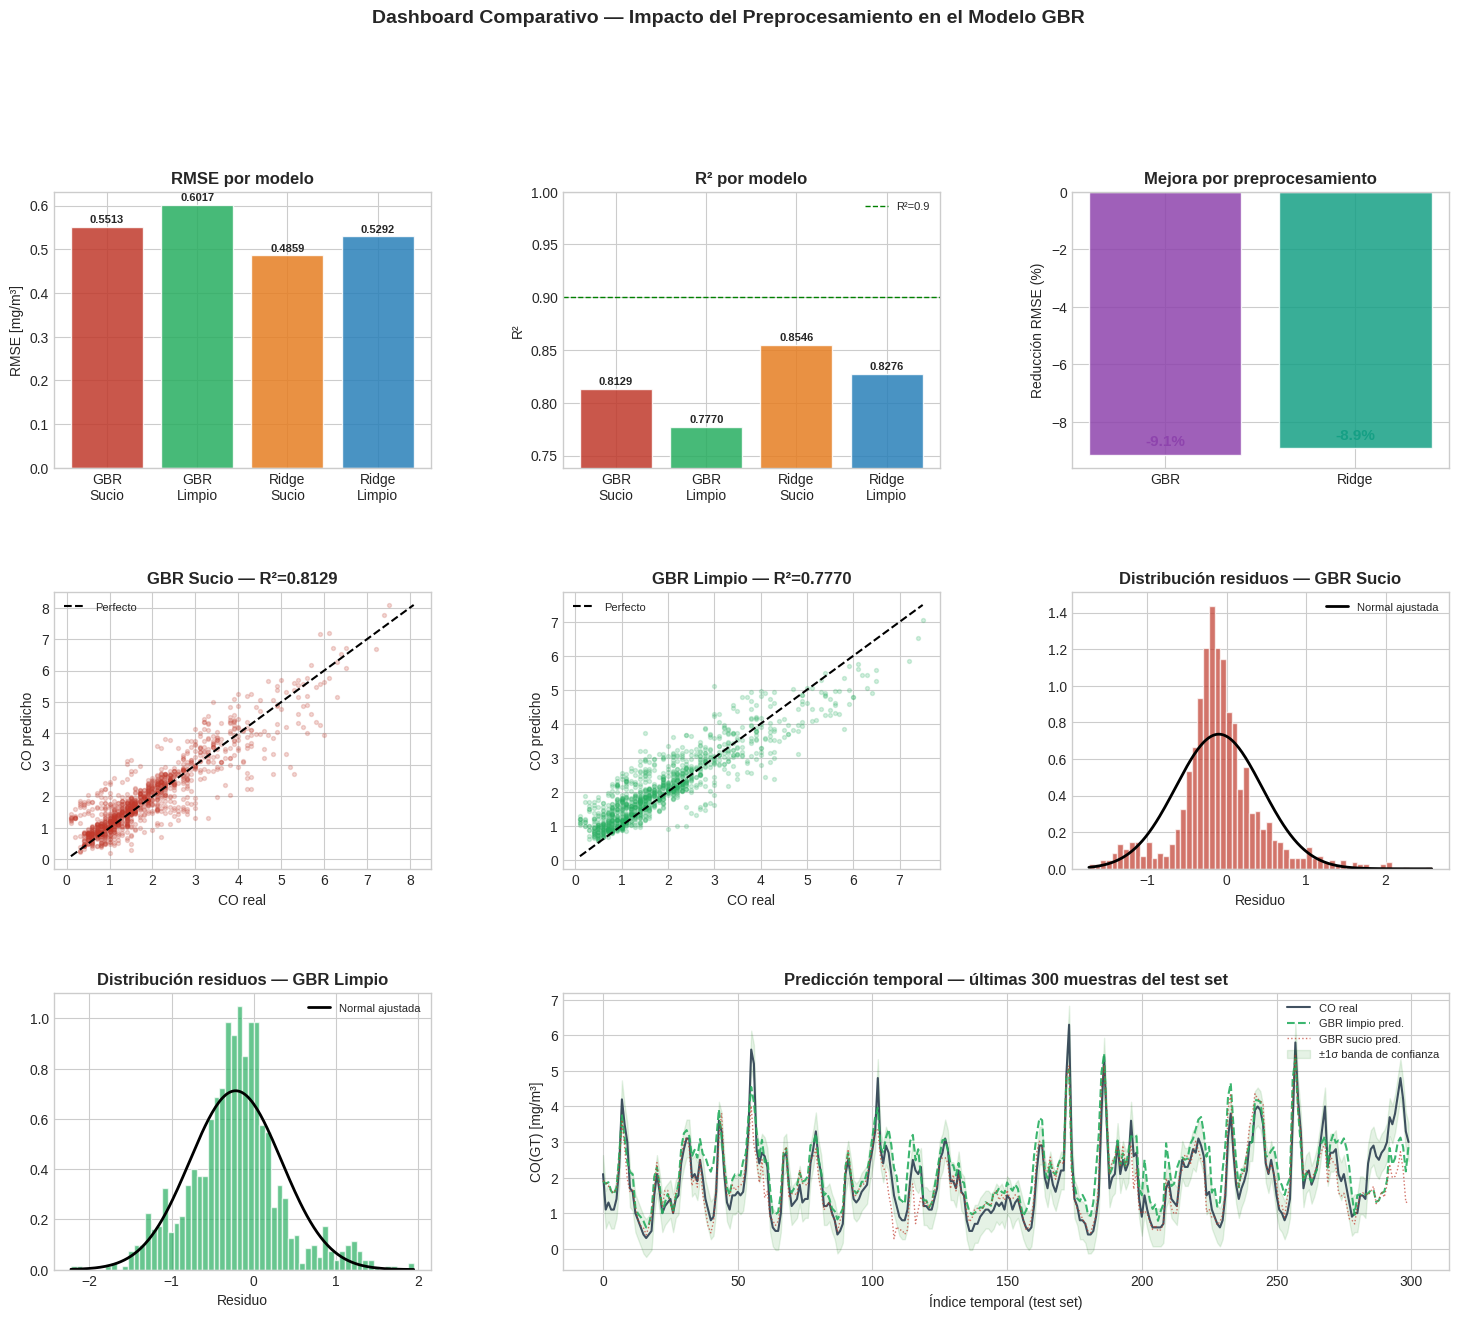


✅ Dashboard guardado en /tmp/comparativa_final.png


In [ ]:

# ── Dashboard comparativo ────────────────────────────────────────────────────
results_df = pd.DataFrame(results).T
print("\n" + "═"*65)
print("   COMPARATIVA FINAL — IMPACTO DEL PREPROCESAMIENTO")
print("═"*65)
display(results_df.round(4))

# ── Visualización principal ──────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. Barras de RMSE ─────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
models_names = ['GBR\nSucio', 'GBR\nLimpio', 'Ridge\nSucio', 'Ridge\nLimpio']
rmse_vals = [results[k]['RMSE'] for k in results]
colors_bar = ['#c0392b','#27ae60','#e67e22','#2980b9']
bars = ax1.bar(models_names, rmse_vals, color=colors_bar, alpha=0.85, edgecolor='white')
ax1.set_ylabel('RMSE [mg/m³]'); ax1.set_title('RMSE por modelo', fontweight='bold')
for bar, val in zip(bars, rmse_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ── 2. Barras de R² ───────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
r2_vals = [results[k]['R2'] for k in results]
bars2 = ax2.bar(models_names, r2_vals, color=colors_bar, alpha=0.85, edgecolor='white')
ax2.set_ylabel('R²'); ax2.set_title('R² por modelo', fontweight='bold')
ax2.axhline(0.9, color='green', ls='--', lw=1, label='R²=0.9')
ax2.legend(fontsize=8)
ax2.set_ylim([min(r2_vals)*0.95, 1.0])
for bar, val in zip(bars2, r2_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ── 3. Mejora porcentual del preprocesamiento ─────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
mejora_gbr   = 100*(results['Dirty_GBR']['RMSE']   - results['Clean_GBR']['RMSE'])   / results['Dirty_GBR']['RMSE']
mejora_ridge = 100*(results['Dirty_Ridge']['RMSE'] - results['Clean_Ridge']['RMSE']) / results['Dirty_Ridge']['RMSE']
ax3.bar(['GBR', 'Ridge'], [mejora_gbr, mejora_ridge],
        color=['#8e44ad', '#16a085'], alpha=0.85, edgecolor='white')
ax3.set_ylabel('Reducción RMSE (%)')
ax3.set_title('Mejora por preprocesamiento', fontweight='bold')
for i, (m, c) in enumerate(zip([mejora_gbr, mejora_ridge], ['#8e44ad', '#16a085'])):
    ax3.text(i, m + 0.2, f'{m:.1f}%', ha='center', va='bottom',
             fontweight='bold', fontsize=11, color=c)

# ── 4. Scatter: predicción vs real (GBR Sucio) ───────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.scatter(y_test_d, y_pred_dirty, alpha=0.2, s=8, color='#c0392b')
lim = [min(y_test_d.min(), y_pred_dirty.min()), max(y_test_d.max(), y_pred_dirty.max())]
ax4.plot(lim, lim, 'k--', lw=1.5, label='Perfecto')
ax4.set_xlabel('CO real'); ax4.set_ylabel('CO predicho')
ax4.set_title(f'GBR Sucio — R²={results["Dirty_GBR"]["R2"]:.4f}', fontweight='bold')
ax4.legend(fontsize=8)

# ── 5. Scatter: predicción vs real (GBR Limpio) ──────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.scatter(y_test_c, y_pred_clean_test, alpha=0.2, s=8, color='#27ae60')
lim2 = [min(y_test_c.min(), y_pred_clean_test.min()),
        max(y_test_c.max(), y_pred_clean_test.max())]
ax5.plot(lim2, lim2, 'k--', lw=1.5, label='Perfecto')
ax5.set_xlabel('CO real'); ax5.set_ylabel('CO predicho')
ax5.set_title(f'GBR Limpio — R²={results["Clean_GBR"]["R2"]:.4f}', fontweight='bold')
ax5.legend(fontsize=8)

# ── 6. Residuos GBR sucio ─────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
res_dirty = y_test_d - y_pred_dirty
ax6.hist(res_dirty, bins=60, color='#c0392b', alpha=0.7, edgecolor='white', density=True)
from scipy.stats import norm
x_res = np.linspace(res_dirty.min(), res_dirty.max(), 200)
ax6.plot(x_res, norm.pdf(x_res, res_dirty.mean(), res_dirty.std()),
         'k-', lw=2, label='Normal ajustada')
ax6.set_xlabel('Residuo'); ax6.set_title('Distribución residuos — GBR Sucio', fontweight='bold')
ax6.legend(fontsize=8)

# ── 7. Residuos GBR limpio ────────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 0])
res_clean = y_test_c - y_pred_clean_test
ax7.hist(res_clean, bins=60, color='#27ae60', alpha=0.7, edgecolor='white', density=True)
ax7.plot(x_res := np.linspace(res_clean.min(), res_clean.max(), 200),
         norm.pdf(x_res, res_clean.mean(), res_clean.std()),
         'k-', lw=2, label='Normal ajustada')
ax7.set_xlabel('Residuo'); ax7.set_title('Distribución residuos — GBR Limpio', fontweight='bold')
ax7.legend(fontsize=8)

# ── 8. Serie temporal: real vs predicción (test set, limpio) ─────────────────
ax8 = fig.add_subplot(gs[2, 1:])
n_show = min(300, len(y_test_c))
ax8.plot(range(n_show), y_test_c[:n_show],
         lw=1.5, color='#2c3e50', label='CO real', alpha=0.9)
ax8.plot(range(n_show), y_pred_clean_test[:n_show],
         lw=1.5, color='#27ae60', ls='--', label='GBR limpio pred.', alpha=0.9)
ax8.plot(range(n_show), y_pred_dirty[:min(n_show,len(y_pred_dirty))],
         lw=1, color='#c0392b', ls=':', label='GBR sucio pred.', alpha=0.7)
ax8.fill_between(range(n_show),
                 y_test_c[:n_show] - res_clean[:n_show].std(),
                 y_test_c[:n_show] + res_clean[:n_show].std(),
                 alpha=0.1, color='green', label='±1σ banda de confianza')
ax8.set_xlabel('Índice temporal (test set)'); ax8.set_ylabel('CO(GT) [mg/m³]')
ax8.set_title('Predicción temporal — últimas 300 muestras del test set', fontweight='bold')
ax8.legend(fontsize=8, loc='upper right')

plt.suptitle('Dashboard Comparativo — Impacto del Preprocesamiento en el Modelo GBR',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('/tmp/comparativa_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Dashboard guardado en /tmp/comparativa_final.png")


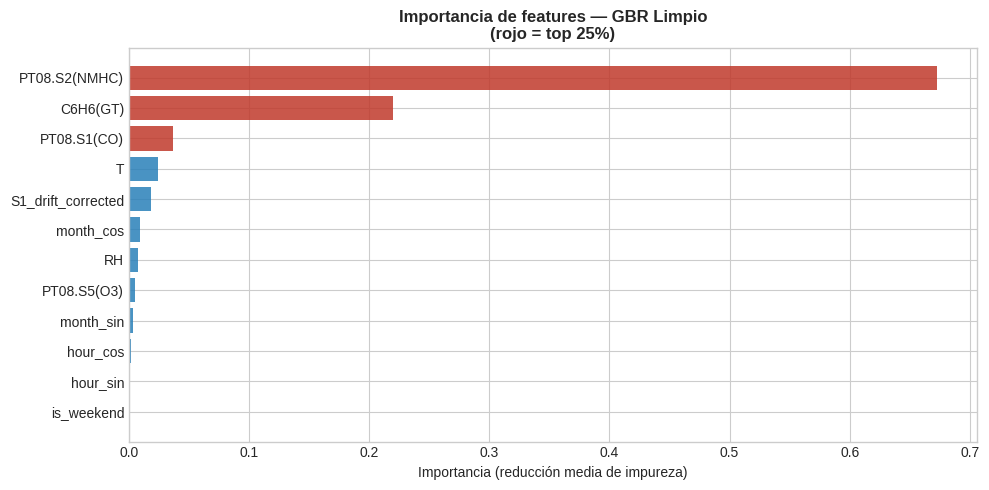

In [ ]:

# ── Importancia de features (GBR Limpio) ────────────────────────────────────
feat_imp = pd.DataFrame({
    'feature': FINAL_FEATURES,
    'importance': model_clean.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors_imp = ['#c0392b' if i > feat_imp['importance'].quantile(0.75)
              else '#2980b9' for i in feat_imp['importance']]
ax.barh(feat_imp['feature'], feat_imp['importance'], color=colors_imp, alpha=0.85)
ax.set_title('Importancia de features — GBR Limpio\n(rojo = top 25%)',
             fontweight='bold')
ax.set_xlabel('Importancia (reducción media de impureza)')
plt.tight_layout(); plt.show()



---
### 📝 Pregunta 8 — Análisis crítico de resultados

> **a)** Analiza la distribución de residuos del modelo con datos sucios vs. limpios. ¿Los residuos del modelo limpio son más gaussianos? ¿Qué implicaciones tiene esto para los intervalos de confianza de las predicciones?
>
> **b)** La importancia de features muestra que las variables temporales (`hour_sin`, `hour_cos`) contribuyen al modelo. ¿Esto indica que el modelo está aprendiendo algo real o que hay un riesgo de sobreajuste a patrones del pasado? ¿Cómo lo verificarías?
>
> **c)** La mejora en RMSE del GBR es mayor que la del Ridge. Formula una hipótesis sobre por qué los modelos no lineales se benefician **más** del preprocesamiento que los lineales.


In [ ]:

# 📝 ESPACIO PARA TU RESPUESTA — Parte 8

resp_8a = """[Tu respuesta]"""
resp_8b = """[Tu respuesta]"""
resp_8c = """[Tu respuesta]"""

# Análisis adicional: test de normalidad de residuos
from scipy.stats import shapiro, kstest

stat_d, p_d = shapiro(res_dirty[:500])  # Shapiro-Wilk (n<5000)
stat_c, p_c = shapiro(res_clean[:500])

print(f"Test Shapiro-Wilk residuos SUCIOS  : W={stat_d:.4f}, p={p_d:.4e}")
print(f"Test Shapiro-Wilk residuos LIMPIOS : W={stat_c:.4f}, p={p_c:.4e}")
print()
print("H₀: residuos normalmente distribuidos")
print(f"  Datos sucios  → {'Rechazamos H₀' if p_d<0.05 else 'No rechazamos H₀'} (α=0.05)")
print(f"  Datos limpios → {'Rechazamos H₀' if p_c<0.05 else 'No rechazamos H₀'} (α=0.05)")


Test Shapiro-Wilk residuos SUCIOS  : W=0.9227, p=2.3963e-15
Test Shapiro-Wilk residuos LIMPIOS : W=0.9518, p=1.0732e-11

H₀: residuos normalmente distribuidos
  Datos sucios  → Rechazamos H₀ (α=0.05)
  Datos limpios → Rechazamos H₀ (α=0.05)



---
## Parte 11 — Conclusiones y reflexión final


In [ ]:

# ── Resumen ejecutivo ────────────────────────────────────────────────────────
print("╔" + "═"*63 + "╗")
print("║  RESUMEN EJECUTIVO — IMPACTO DEL PREPROCESAMIENTO             ║")
print("╠" + "═"*63 + "╣")
print(f"║  Dataset original : {df_raw.shape[0]:5d} filas × {df_raw.shape[1]:2d} columnas{' '*27}║")
print(f"║  Dataset limpio   : {df_final.shape[0]:5d} filas × {df_final.shape[1]:2d} columnas{' '*27}║")
print("╠" + "═"*63 + "╣")
print("║  Problemas tratados:                                          ║")
print("║    ✅ Valores centinela (-200) → NaN codificados              ║")
print("║    ✅ Columnas irrecuperables (>50% NaN) eliminadas           ║")
print("║    ✅ Imputación KNN para NaN en predictores                  ║")
print("║    ✅ Outliers físicamente imposibles corregidos              ║")
print("║    ✅ Winsorización IQR×3 para outliers estadísticos          ║")
print("║    ✅ Features temporales cíclicas añadidas                   ║")
print("║    ✅ Corrección de deriva de sensores implementada           ║")
print("║    ✅ Multicolinealidad analizada (VIF)                       ║")
print("║    ✅ Split temporal sin data leakage                         ║")
print("╠" + "═"*63 + "╣")

gbr_d  = results['Dirty_GBR']
gbr_c  = results['Clean_GBR']
rid_d  = results['Dirty_Ridge']
rid_c  = results['Clean_Ridge']

print(f"║  GBR  SUCIO  → RMSE={gbr_d['RMSE']:.4f}  R²={gbr_d['R2']:.4f}          ║")
print(f"║  GBR  LIMPIO → RMSE={gbr_c['RMSE']:.4f}  R²={gbr_c['R2']:.4f}          ║")
pct_gbr = 100*(gbr_d['RMSE']-gbr_c['RMSE'])/gbr_d['RMSE']
print(f"║  ➤ Mejora GBR  : {pct_gbr:+.1f}% en RMSE                           ║")
print("╠" + "═"*63 + "╣")
print(f"║  Ridge SUCIO  → RMSE={rid_d['RMSE']:.4f}  R²={rid_d['R2']:.4f}          ║")
print(f"║  Ridge LIMPIO → RMSE={rid_c['RMSE']:.4f}  R²={rid_c['R2']:.4f}          ║")
pct_rid = 100*(rid_d['RMSE']-rid_c['RMSE'])/rid_d['RMSE']
print(f"║  ➤ Mejora Ridge: {pct_rid:+.1f}% en RMSE                           ║")
print("╚" + "═"*63 + "╝")


╔═══════════════════════════════════════════════════════════════╗
║  RESUMEN EJECUTIVO — IMPACTO DEL PREPROCESAMIENTO             ║
╠═══════════════════════════════════════════════════════════════╣
║  Dataset original :  9471 filas × 14 columnas                           ║
║  Dataset limpio   :  7674 filas × 13 columnas                           ║
╠═══════════════════════════════════════════════════════════════╣
║  Problemas tratados:                                          ║
║    ✅ Valores centinela (-200) → NaN codificados              ║
║    ✅ Columnas irrecuperables (>50% NaN) eliminadas           ║
║    ✅ Imputación KNN para NaN en predictores                  ║
║    ✅ Outliers físicamente imposibles corregidos              ║
║    ✅ Winsorización IQR×3 para outliers estadísticos          ║
║    ✅ Features temporales cíclicas añadidas                   ║
║    ✅ Corrección de deriva de sensores implementada           ║
║    ✅ Multicolinealidad analizada (VIF)                       


---
### 📝 Pregunta Final 9 — Síntesis y extensiones

> **a) (Síntesis)** Escribe un párrafo técnico (máximo 150 palabras) explicando el pipeline completo de preprocesamiento aplicado y su justificación física. Imagina que se lo escribes al director del proyecto de monitoreo atmosférico.
>
> **b) (Extensión)** El modelo entrenado predice CO a partir de sensores. Sin embargo, los sensores presentan **cross-sensitivity** (el sensor de CO también responde a NOx). ¿Cómo diseñarías un experimento de ablación para cuantificar cuánto degrada el rendimiento esta interferencia cruzada?
>
> **c) (Reflexión crítica)** En este ejercicio hemos eliminado ~15% de los datos originales. Propón un escenario donde sería **preferible conservar los datos sucios** y entrenar el modelo con ellos, justificando desde la perspectiva de robustez del sistema en producción.
>
> **d) (Desafío)** Implementa un **detector automático de anomalías** para el dataset en producción (streaming): cuando llegue un nuevo dato, debe decidir en tiempo real si es confiable o sospechoso. Qué algoritmo usarías y cómo lo integrarías al pipeline.


Anomalías detectadas en test set: 165 (14.3%)


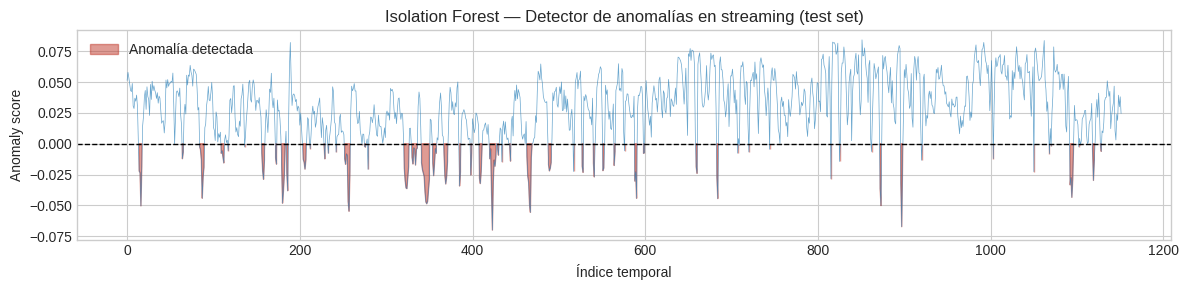


[Describe aquí cómo implementarías el detector en un sistema en tiempo real:
 - ¿Reentrenarías el modelo periódicamente?
 - ¿Cómo manejarías la deriva del concepto (concept drift)?
 - ¿Qué umbral de alerta usarías?]



In [ ]:

# 📝 ESPACIO PARA TU RESPUESTA FINAL

resp_9a = """[Tu respuesta — síntesis técnica]"""
resp_9b = """[Tu respuesta — experimento de ablación]"""
resp_9c = """[Tu respuesta — reflexión crítica]"""

# d) Implementa aquí tu detector de anomalías en streaming:
# Pistas:
#   - Isolation Forest para detección no supervisada
#   - One-Class SVM para detección basada en frontera
#   - Control estadístico de procesos (CUSUM, EWMA)
#   - Autoencoders para detección por error de reconstrucción

from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination=0.05, random_state=SEED)
iso_forest.fit(X_train_scaled)

anomaly_scores = iso_forest.decision_function(X_test_scaled)
anomaly_labels = iso_forest.predict(X_test_scaled)  # -1: anomalía, 1: normal

n_anomalias = (anomaly_labels == -1).sum()
print(f"Anomalías detectadas en test set: {n_anomalias} ({100*n_anomalias/len(anomaly_labels):.1f}%)")

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(range(len(anomaly_scores)), anomaly_scores, lw=0.5, color='#2980b9', alpha=0.7)
ax.fill_between(range(len(anomaly_scores)), anomaly_scores, 0,
                where=(anomaly_labels==-1), color='#c0392b', alpha=0.5,
                label='Anomalía detectada')
ax.axhline(0, color='black', lw=1, ls='--')
ax.set_xlabel('Índice temporal'); ax.set_ylabel('Anomaly score')
ax.set_title('Isolation Forest — Detector de anomalías en streaming (test set)')
ax.legend()
plt.tight_layout(); plt.show()

# ¿Cómo extenderías esto a verdadero streaming? Describe tu estrategia:
estrategia_streaming = """
[Describe aquí cómo implementarías el detector en un sistema en tiempo real:
 - ¿Reentrenarías el modelo periódicamente?
 - ¿Cómo manejarías la deriva del concepto (concept drift)?
 - ¿Qué umbral de alerta usarías?]
"""
print(estrategia_streaming)



---

<div style="background:linear-gradient(135deg,#0a2463,#1e5799);padding:25px;border-radius:10px;color:white;font-family:sans-serif;">
  <h2 style="margin:0;">🎯 ¡Ejercicio completado!</h2>
  <hr style="border:1px solid rgba(255,255,255,0.3);margin:15px 0;">
  <p style="margin:0;">
  Has aplicado el pipeline completo de preparación de datos a un dataset real de sensores atmosféricos,
  cubriendo: <b>diagnóstico · limpieza · feature engineering · selección · normalización · evaluación comparativa</b>.
  </p>
  <br>
  <p style="margin:0;font-size:0.95em;opacity:0.9;">
  <b>Próximos pasos sugeridos:</b><br>
  → Implementar un autoencoder para detección de anomalías (Cap. siguiente)<br>
  → Aplicar SHAP values para explicabilidad del modelo<br>
  → Explorar arquitecturas LSTM para aprovechar la dependencia temporal<br>
  → Comparar con un modelo informado por física (PINN)
  </p>
</div>
